In [1]:
import os
import numpy as np
import cv2
from PIL import Image
from matplotlib import pyplot as plt

In [2]:
pmatrix_new = np.load('./data/pmatrix_new.npy')
new_w = int(np.load('./data/new_w.npy'))
new_h = int(np.load('./data/new_h.npy'))

coord [9618434, 9622550, 9626138, 9629313, 9632558, 9635725, 9639484, 9643967, 9650043, 9655672]
coord ['./data/4/masks\\009618.434.npy', './data/4/masks\\009622.550.npy', './data/4/masks\\009626.138.npy', './data/4/masks\\009629.313.npy', './data/4/masks\\009632.558.npy', './data/4/masks\\009635.725.npy', './data/4/masks\\009639.484.npy', './data/4/masks\\009643.967.npy', './data/4/masks\\009650.043.npy', './data/4/masks\\009655.672.npy']
(28522, 14268)


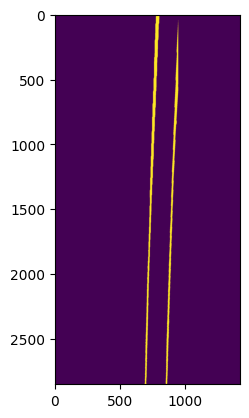

In [3]:
src = r'./data/4/masks'
img_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.jpg')]
msk_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.npy')]

import re
coord = []

msk_fs = msk_fs  # временно для тестов

for f in msk_fs:
    match = re.search(r'(\d+\.\d{3,})', f)
    if match:
        result = match.group(1)
        coord.append(int(float(result)*1000))  # переводим координаты в мм

print('coord', coord[:10])
print('coord', msk_fs[:10])


def load_warp(mask_path):
    mask = np.load(mask_path)
    mask = np.array(mask, dtype=np.uint8)
    res = cv2.warpPerspective(mask, pmatrix_new, (new_w, new_h))
    res[:, :int(res.shape[1]/3)] = 0
    res[:, -int(res.shape[1]/3):] = 0
    return res

def resize(arr):
    # scale = 1000 / max(arr.shape)
    scale = 0.1
    display_res = cv2.resize(arr, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    return display_res

# fig, ax = plt.subplots()

# # mask_pr = load_warp(r"D:\Projects\perspective\data\3\080843.789.jpg")
mask_pr = load_warp(msk_fs[20])

print(mask_pr.shape)
plt.imshow(resize(mask_pr))

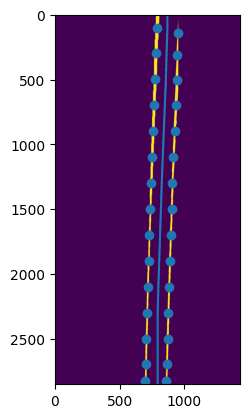

In [5]:
def bend(mask, shift=200):
    """гнёт вправо для тестов"""
    h, w = mask.shape[:2]
    # Исходные углы (порядок: верх-лево, верх-право, низ-право, низ-лево)
    src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])

    dst = np.float32([
        [shift, 0],        # верх-лево → вправо
        [w + shift, 0],    # верх-право → влево
        [w, h],            # низ-право — на месте
        [0, h]             # низ-лево — на месте
    ])
    # Матрица и преобразование
    M = cv2.getPerspectiveTransform(src, dst)
    result = cv2.warpPerspective(mask, M, (w, h))
    return result


# поворот
def rotate(rect, angle, point):
    """angle в радианах
       point точка вокруг которой повернуть
       полож знач пов против часовой
    """
    c, s = np.cos(angle), np.sin(angle)
    rotation_matrix = np.array([
        [c, -s],
        [s,  c]
    ])

    shifted_rect = rect - point
    rotated_rectangle = (rotation_matrix @ shifted_rect.T).T + point
    return rotated_rectangle


def find_rail_dots(mask, step=2000):
    # далее можно сократить расчеты
    """[Y, X] для рельсов, [y_centr, x_centr] для центр точек"""
    centroids = []

    height = mask.shape[0]
    num_steps = int(np.ceil(height / step))

    for i in range(num_steps):
        st = i * step
        en = np.min((st + step, height))
        contours, _ = cv2.findContours(mask[st:en, :], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        for contour in contours:
            M = cv2.moments(contour)
            if M["m00"] != 0:  # Проверяем, чтобы избежать деления на ноль
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                centroids.append((cx, cy+st))

    X = np.array(centroids)[:, 0]
    Y = np.array(centroids)[:, 1]
    diff = np.diff(Y)
    # ищет пары близких центроидов (где вертикальное расстояние меньше 3 пикселей) и вычисляет для них среднюю точку по X

    mid_p = []
    for i, v in enumerate(diff):
        if v < 3:
            mid_x = int((X[i] + X[i+1]) / 2)
            mid_y = int((Y[i] + Y[i+1]) / 2)
            mid_p.append([mid_x, mid_y])

    mid_p = np.array(mid_p) # точки между центроидами
    # Интеролировать серединки для всех У
    y_centr = np.arange(mask.shape[0])
    x_centr = np.interp(y_centr, mid_p[:, 1], mid_p[:, 0])

    return np.array([Y, X]), np.array([y_centr, x_centr])


YX, yx_centr = find_rail_dots(mask_pr)

plt.imshow(resize(mask_pr))
plt.scatter(YX[1, :]//10, YX[0, :]//10)
plt.plot(yx_centr[1, :]//10, yx_centr[0, :]//10)
plt.margins(0, 0)

0.19739555984988075


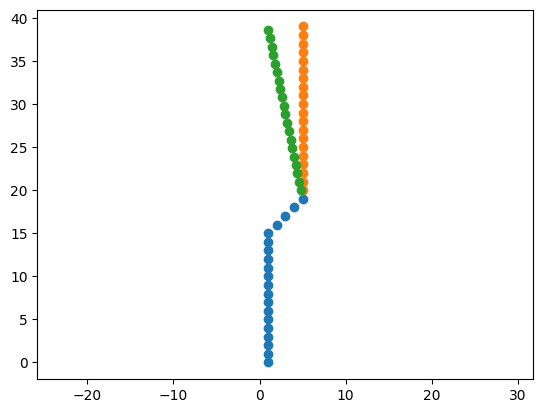

In [992]:
a1 = np.array([np.ones(20), np.arange(20)])
a1[0, 15:] += np.arange(5)



a2 = np.array([np.ones(20), np.arange(20, 40)])
a2[0, :] += 4

p2 = a2.T[-1]
p1 = a1.T[0]
p0 = [1, 19]

dx = p2[0] - p0[0]
dy = p2[1] - p0[1]

angle = np.arctan2(dx, dy)

print(angle)

a3 = rotate(a2.T, 0.2, a1.T[-1]).T  # повернуть на минус angle

plt.scatter(a1[0, :], a1[1, :])
plt.scatter(a2[0, :], a2[1, :])
plt.scatter(a3[0, :], a3[1, :])
plt.axis('equal');

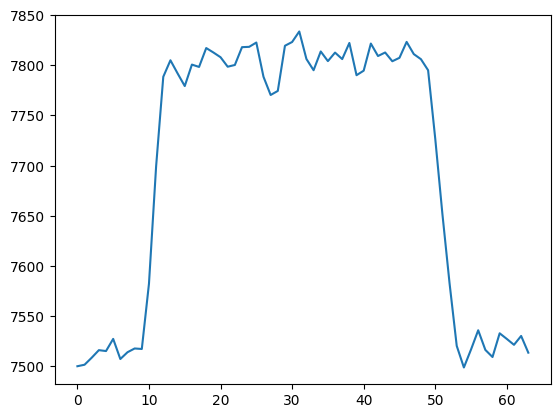

In [553]:
plt.plot(niz_all[1:])

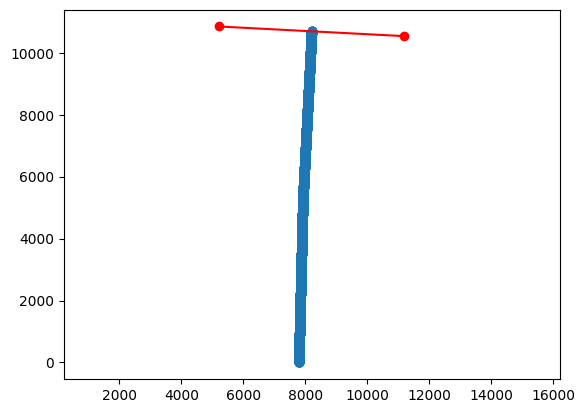

In [830]:
p1, p2 = yx_centr[-1][::-1], yx_centr[0][::-1]
# 2. Расчет направляющего вектора линии
v = p2 - p1
# 3. Нахождение перпендикулярного вектора (поворот на 90 градусов)
# Для вектора (x, y) перпендикуляр равен (-y, x)
v_perp = np.array([-v[1], v[0]])
length = 3000.0
v_perp_normalized = v_perp / np.linalg.norm(v_perp) * length
p3 = p2 + v_perp_normalized
p4 = p2 - v_perp_normalized

dx = p4[0] - p3[0]
dy = p4[1] - p3[1]
(np.arctan2(dy, dx))

plt.scatter(Array[:, 1], Array[:, 0])
plt.plot([p3[0], p4[0]], [p3[1], p4[1]], "r-o")
plt.axis('equal')
plt.show()

angle 0.1973955598498806      11


(np.float64(4.764083770219964),
 np.float64(11.235916229780036),
 np.float64(-0.5294174202707276),
 np.float64(11.117765825685279))

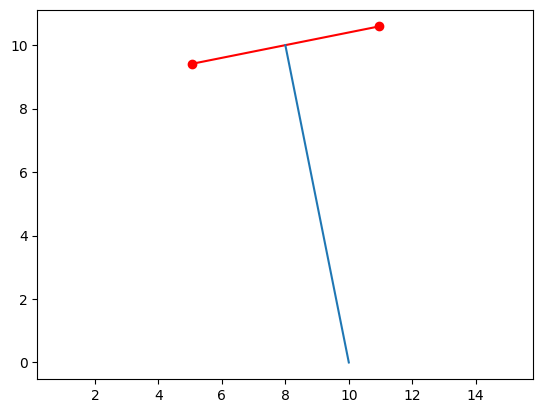

In [856]:
p1, p2 = np.array([10, 0]), np.array([8, 10])

line = np.linspace(p1, p2, 20)

v = p2 - p1
v_perp = np.array([-v[1], v[0]])
length = 3.0
v_perp_normalized = v_perp / np.linalg.norm(v_perp) * length
p3 = p2 + v_perp_normalized
p4 = p2 - v_perp_normalized

dx = p4[0] - p3[0]
dy = p4[1] - p3[1]
angle = np.arctan2(dy, dx)
print('angle', angle, '    ', np.int16(np.degrees(angle)))

plt.plot([p3[0], p4[0]], [p3[1], p4[1]], "r-o")
plt.plot(line[:, 0], line[:, 1])
plt.axis('equal')

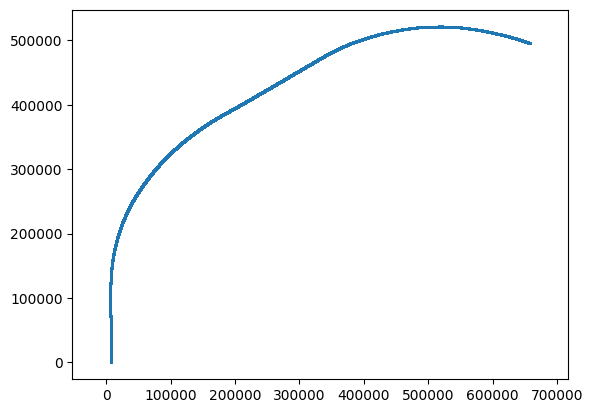

In [188]:
"""
вар № 1
поворачивает текущую картинку на угол наклона, но похоже это не то
смещает по Х и по У
"""
# yx_centr низ [-1], верх [0]
Array = np.zeros((1, 2))
angle_all = np.zeros((1))

niz_all = np.zeros((1, 1))
verx_all = np.zeros((1, 1))

x_norm = 7513. # (mask.shape[1] // 2) + 379

x_test = 0

angle = 0
coef = 0
shift = 0
for i, (m_f, c) in enumerate(zip(msk_fs[0:-1], coord[0:-1])):  # 0:-1 0:2 13:14 20:22 20:32 29:32
    mask = load_warp(m_f)
    mask = mask[mask.shape[0]-(coord[i+1] - coord[i]): mask.shape[0]+1]  # низ маски. низ - текущ коорд, верх след коорд (включительно)

    # mask = bend(mask, shift=2000)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=200)
    # plt.imshow(resize(mask))
    # plt.plot(yx_centr[1, :]//10, yx_centr[0, :]//10)
    # plt.axvline((mask.shape[1] // 20)+38, c='g')
    # plt.show()

    # преобразовать ось Y (переворот). Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    yx_centr = yx_centr.T
    _y = yx_centr[:, 0]
    _y = _y[::-1]
    yx_centr[:, 0] = _y
    # ===========================================
    # лин регрессия
    kb = np.polyfit(yx_centr[:, 0], yx_centr[:, 1], 1)
    f = np.poly1d(kb)
    y_n = np.arange(yx_centr.shape[0])
    x_lin = f(yx_centr[:, 0])
    yx_centr[:, 1] = x_lin
    # ===========================================
    # для первой итерации
    if i == 0:
        pass
    else:
        # смещение по У
        yx_centr[:, 0] += coef

        # для поворот
        b0 = yx_centr[-1][::-1]  # xy
        _b0 = [b0[0], yx_centr[0, 0]]  # проекция b0 на верхн грани
        b = yx_centr[0][::-1]  # xy

        dy = _b0[1] - b0[1]
        dx = b[0] - b0[0]

        _angle = np.arctan2(dx, dy)
        angle += _angle  # накопить угол

        # смещение по Х
        # сдвинуть центр в точку, где она находилась в предыдущ кадре
        shift = a - yx_centr[-1, 1]
        yx_centr[:, 1] += shift
    # для поворота
    yx_centr = rotate(yx_centr[:, [1, 0]], -angle, yx_centr[-1, [1, 0]])[:, [1, 0]]
    # обновл коорд Y на пройденный путь
    coef += yx_centr[0, 0] - yx_centr[-1, 0]  # shape тут не подходит, т.к. не измен после поворота

    # для смещения по Х
    a = yx_centr[0, 1]


    # print('пройденное', np.int32(coef))

    Array = np.vstack((Array, yx_centr))
    angle_all = np.vstack((angle_all, angle))
Array = Array[1:, :]  # убир перв строка, кот 0 0

plt.scatter(Array[:, 1], Array[:, 0], s=1)
plt.axis('equal')
plt.show()


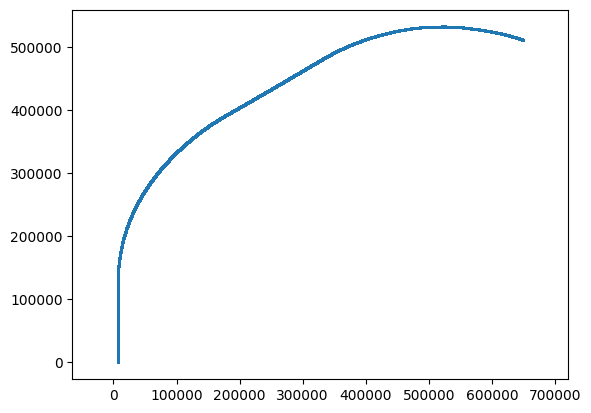

In [190]:
"""
вар № 2
к верхней точке текущего проводит перепендикуляр, на этот угол поворачивает след кадр,
"""
# yx_centr низ [-1], верх [0]
Array = np.zeros((1, 2))

angle_all = np.zeros((1))

x_test = 0

angle = 0
coef = 0
shift = 0
for i, (m_f, c) in enumerate(zip(msk_fs[0:-1], coord[0:-1])):  # 0:-1 0:2 13:14 20:22 20:32 29:32
    mask = load_warp(m_f)
    mask = mask[mask.shape[0]-(coord[i+1] - coord[i]): mask.shape[0]+1]  # низ маски. низ - текущ коорд, верх след коорд (включительно)

    # mask = bend(mask, shift=2000)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=200)
    # plt.imshow(resize(mask))
    # plt.plot(yx_centr[:, 1]//10, yx_centr[:, 0]//10)
    # plt.axvline((mask.shape[1] // 20)+38, c='g')
    # plt.show()

    # преобразовать ось Y (переворот). Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    yx_centr = yx_centr.T
    _y = yx_centr[:, 0]
    _y = _y[::-1]
    yx_centr[:, 0] = _y
    # ===========================================
    # лин регрессия
    kb = np.polyfit(yx_centr[:, 0], yx_centr[:, 1], 1)
    f = np.poly1d(kb)
    y_n = np.arange(yx_centr.shape[0])
    x_lin = f(yx_centr[:, 0])
    yx_centr[:, 1] = x_lin
    # ===========================================
    # для первой итерации
    if i == 0:
        pass
    else:
        # смещение по X
        shift = a - yx_centr[-1, 1]
        yx_centr[:, 1] += shift

    # смещение по У
    yx_centr[:, 0] += coef


    if not angle:
        pass
    else:
        yx_centr = rotate(yx_centr[:, [1, 0]], angle, yx_centr[-1, [1, 0]])[:, [1, 0]]

    p1, p2 = yx_centr[-1][::-1], yx_centr[0][::-1]
    p1, p2
    # 2. Расчет направляющего вектора линии
    v = p2 - p1
    # 3. Нахождение перпендикулярного вектора (поворот на 90 градусов)
    # Для вектора (x, y) перпендикуляр равен (-y, x)
    v_perp = np.array([-v[1], v[0]])
    length = 3000.0
    v_perp_normalized = v_perp / np.linalg.norm(v_perp) * length
    p3 = p2 + v_perp_normalized
    p4 = p2 - v_perp_normalized
    # print(p3[0] - p4[0])

    dx = p4[0] - p3[0]
    dy = p4[1] - p3[1]

    angle = np.arctan2(dy, dx)

    # обновл коорд Y на пройденный путь
    coef += yx_centr[0, 0] - yx_centr[-1, 0]  # shape тут не подходит, т.к. не измен после поворота

    # для смещения по Х
    a = yx_centr[0, 1]

    # print('пройденное', np.int32(coef))


    Array = np.vstack((Array, yx_centr))
    angle_all = np.vstack((angle_all, angle))
Array = Array[1:, :]  # убир перв строка, кот 0 0
angle_all = angle_all[1:, :]

plt.scatter(Array[:, 1], Array[:, 0], s=1)
plt.axis('equal')
plt.show()


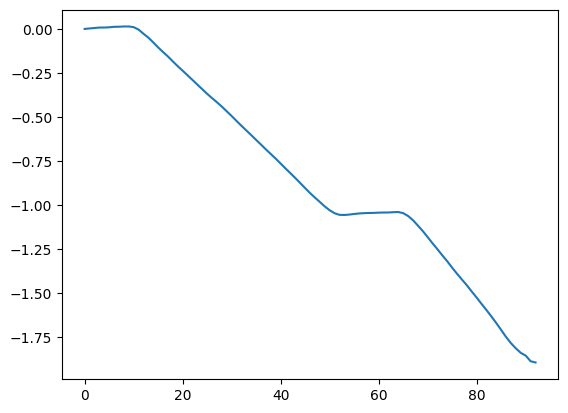

In [191]:
plt.plot(angle_all[:])

(np.float64(2854380.2303763237),
 np.float64(2854843.9019218097),
 np.float64(2198056.3348339563),
 np.float64(2199545.6181540876))

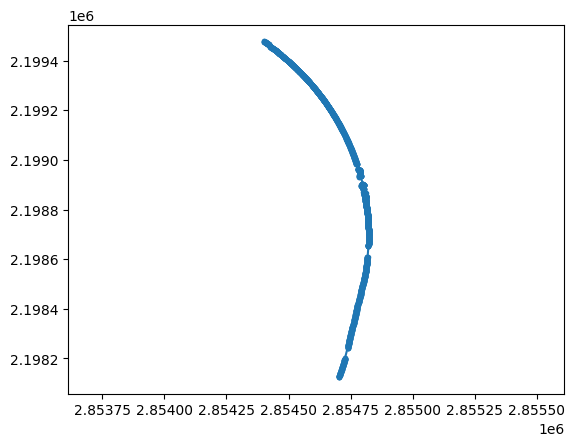

In [11]:
data = np.load(r"\\10.3.3.100\d\temp\Для Андрея\Для плана по обзорным камерам\dc_x_y_z.npy")
st, en = np.searchsorted(data[:, 0], [9618.434, 011241.841])
plt.plot(data[st:en, 1], data[st:en, 2], marker='.')
plt.axis('equal')

(np.float64(2839625.2200178425),
 np.float64(2855596.0697558615),
 np.float64(2184891.017169716),
 np.float64(2203601.170179997))

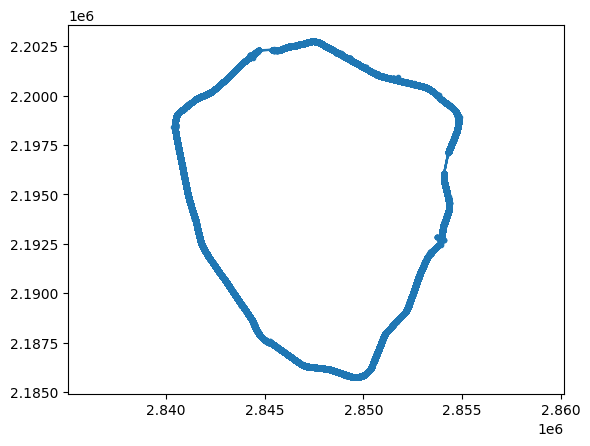

In [894]:
plt.plot(data[:, 1], data[:, 2], marker='.')
plt.axis('equal')

0


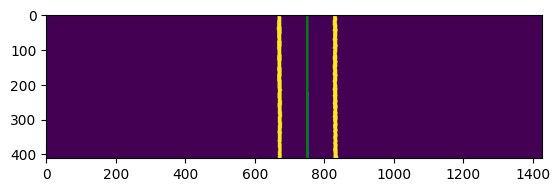

1


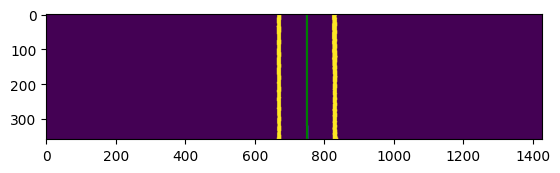

2


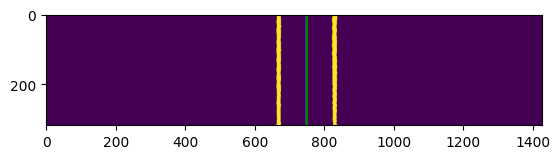

3


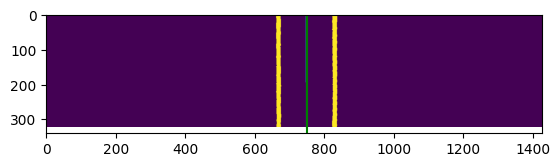

4


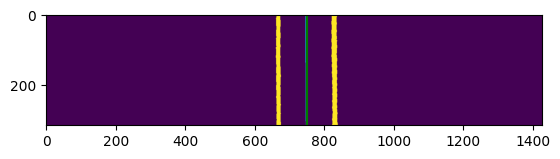

5


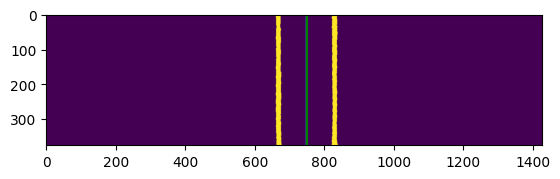

6


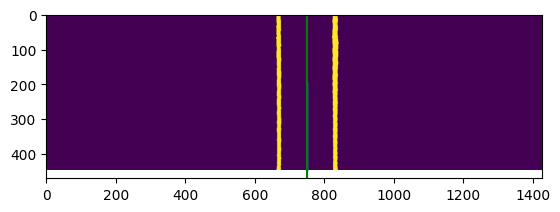

7


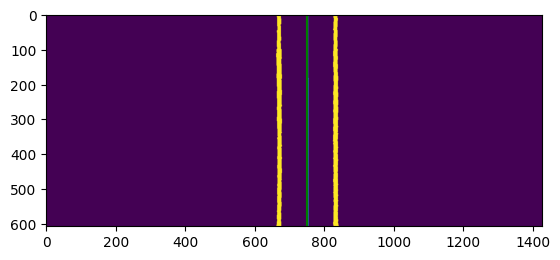

8


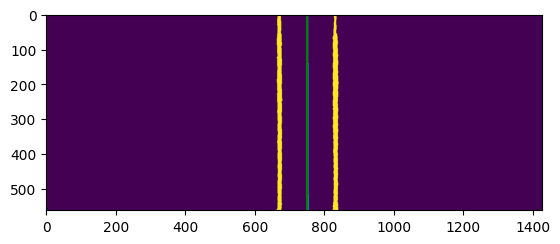

9


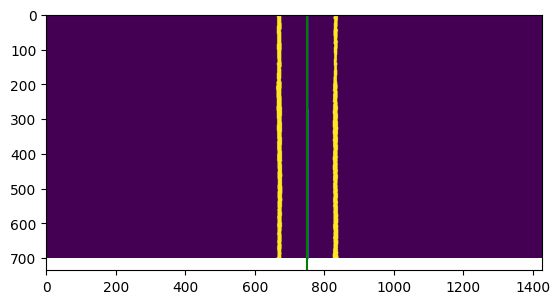

10


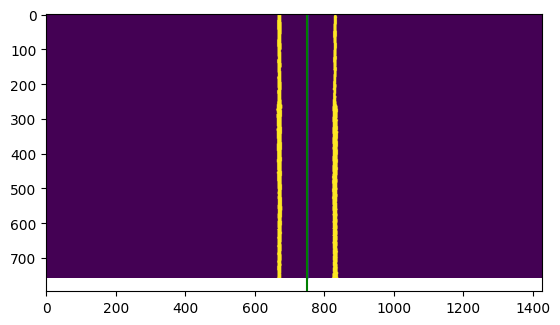

11


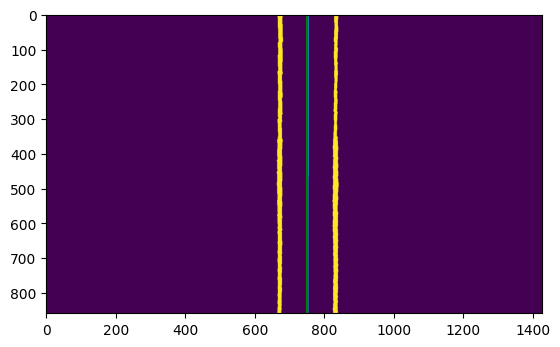

12


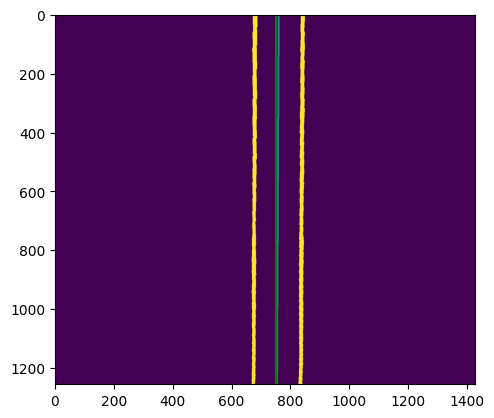

13


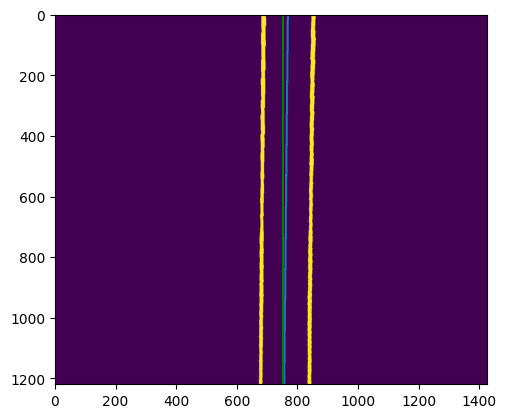

14


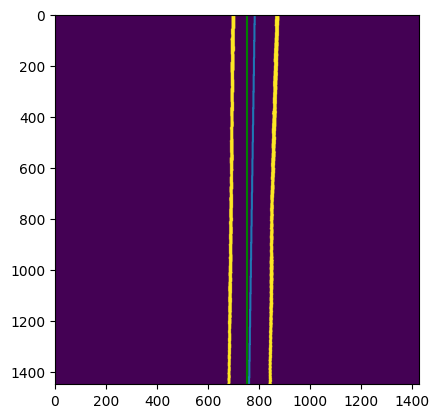

15


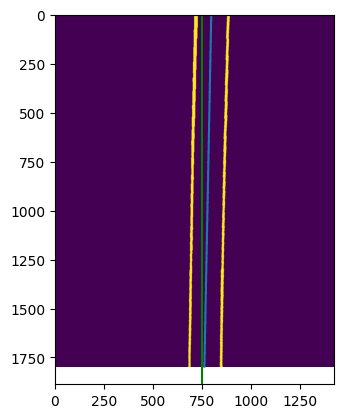

16


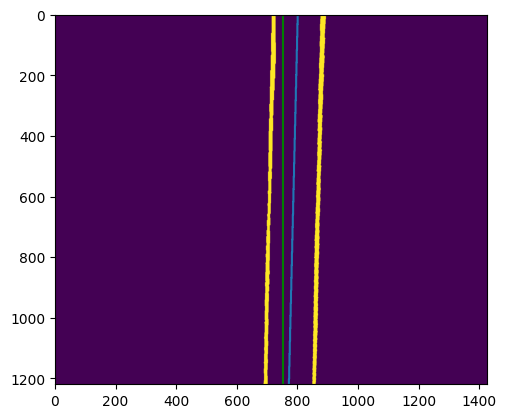

17


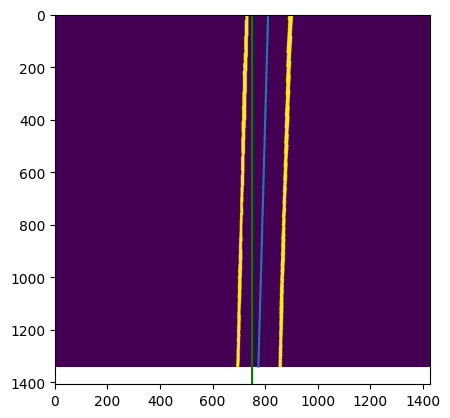

18


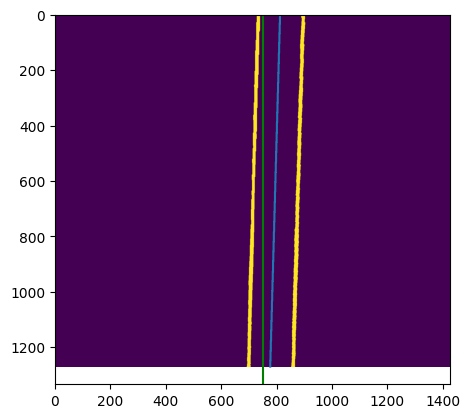

19


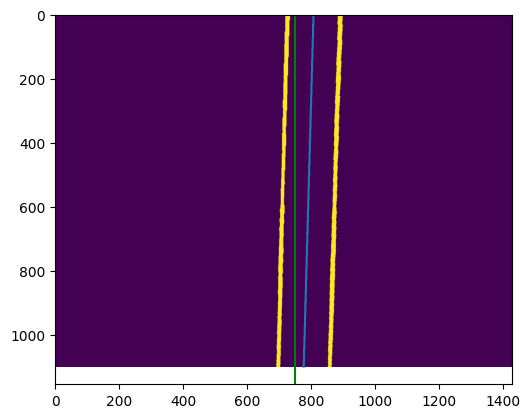

20


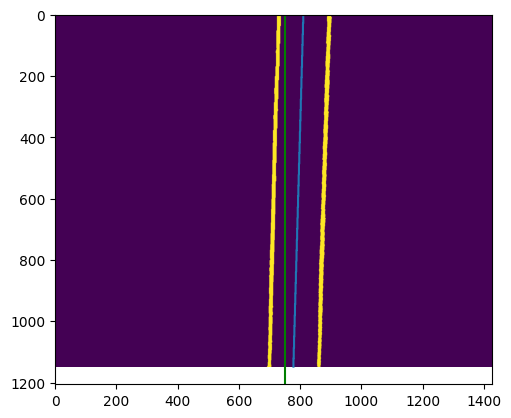

21


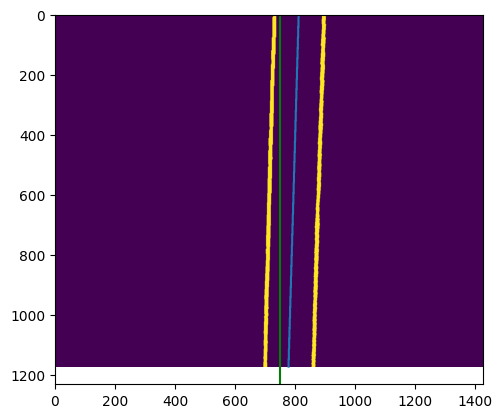

22


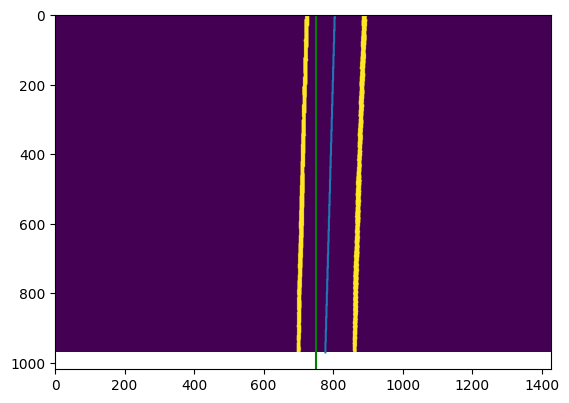

23


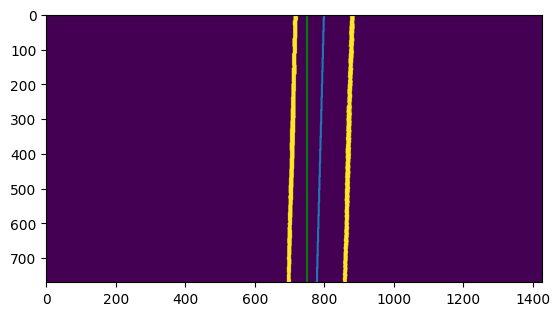

24


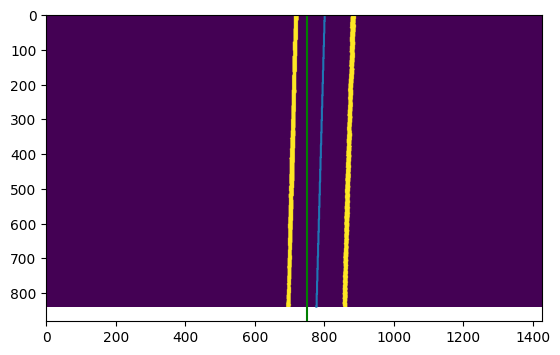

25


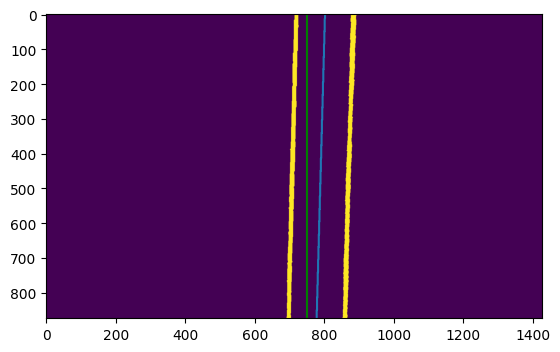

26


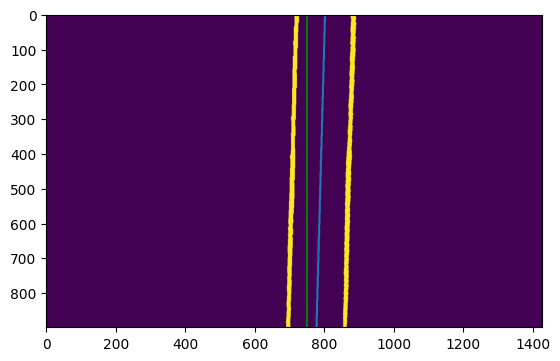

27


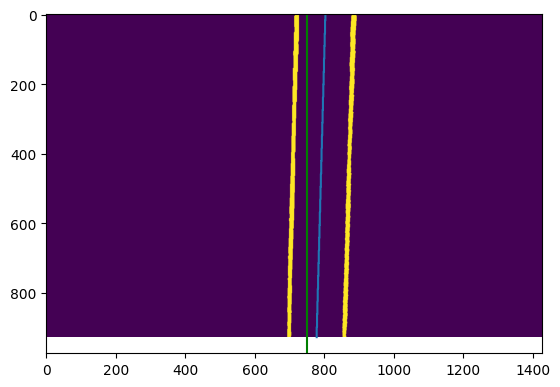

28


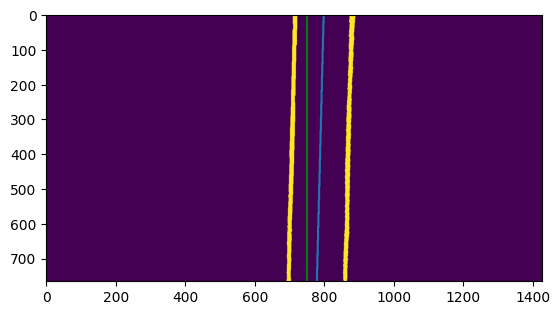

29


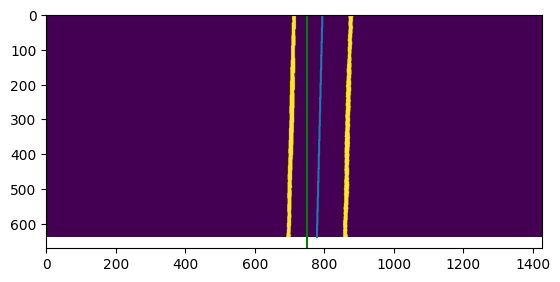

30


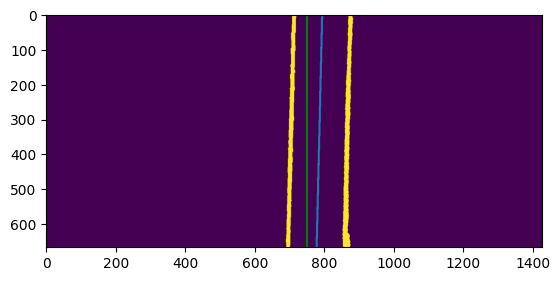

31


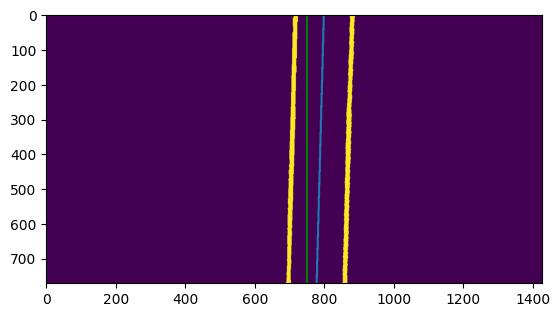

32


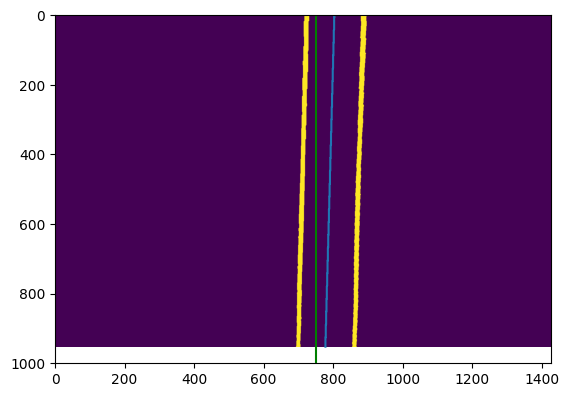

33


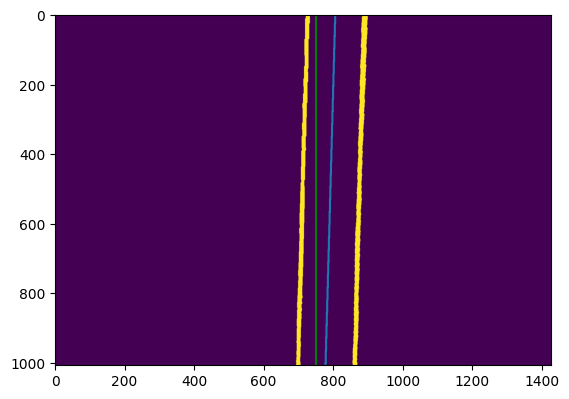

34


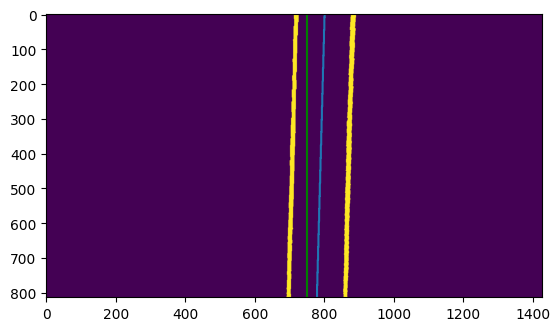

35


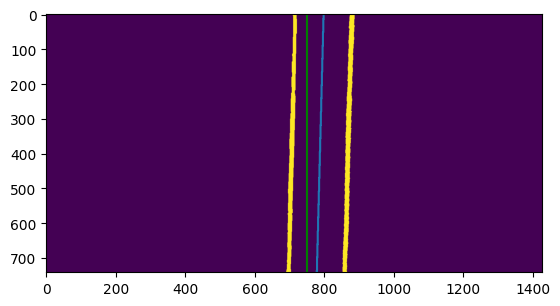

36


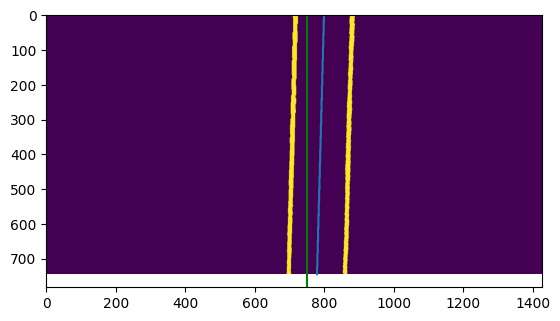

37


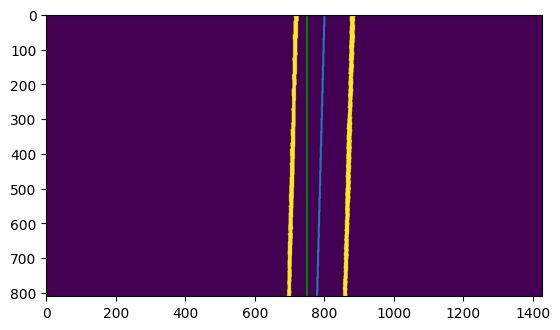

38


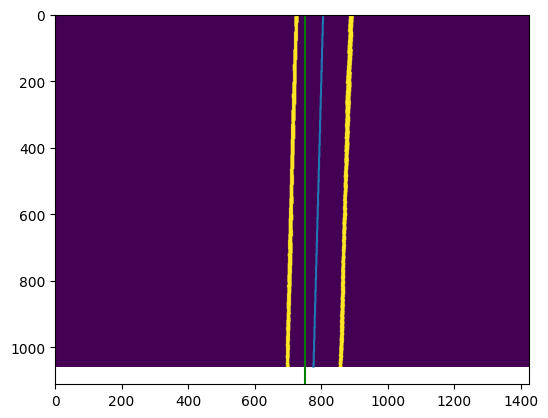

39


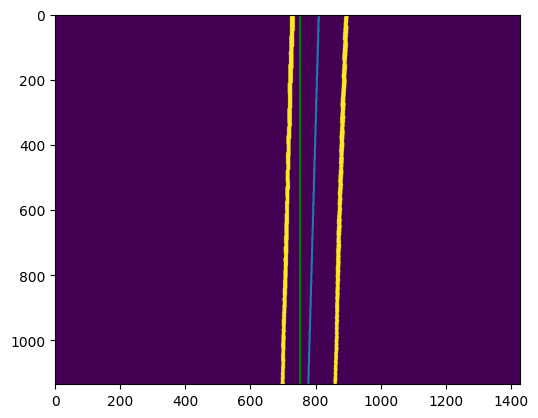

40


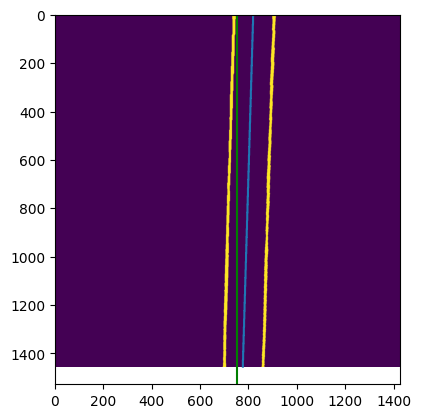

41


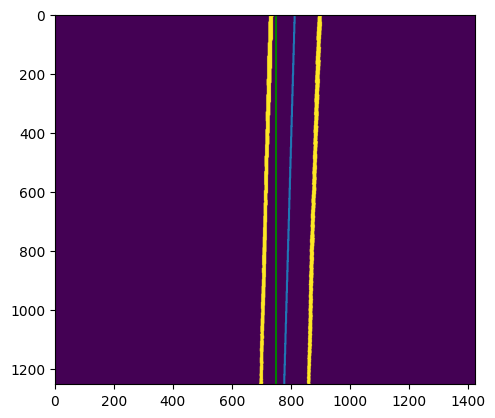

42


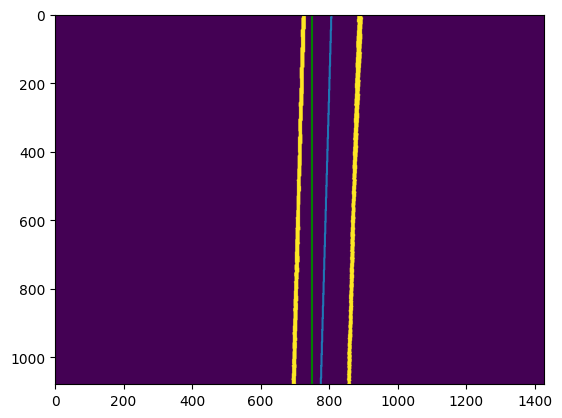

43


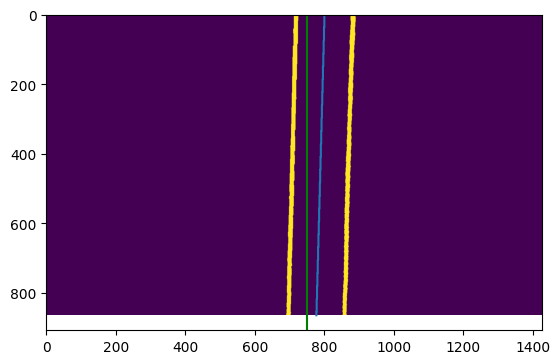

44


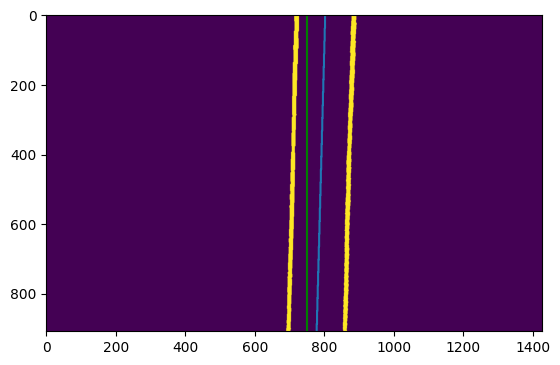

45


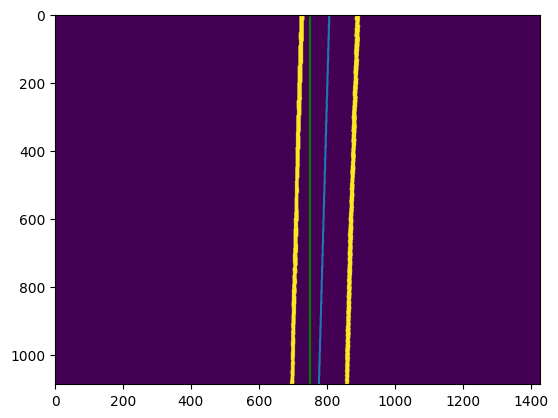

46


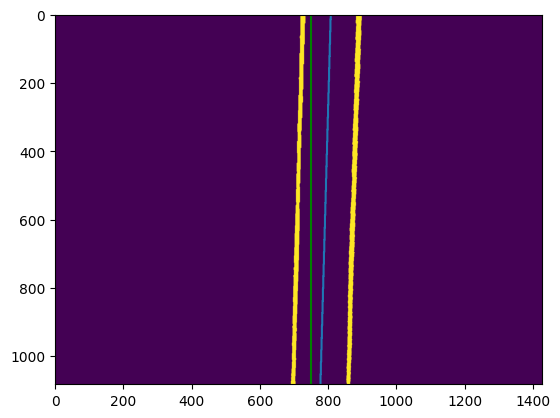

47


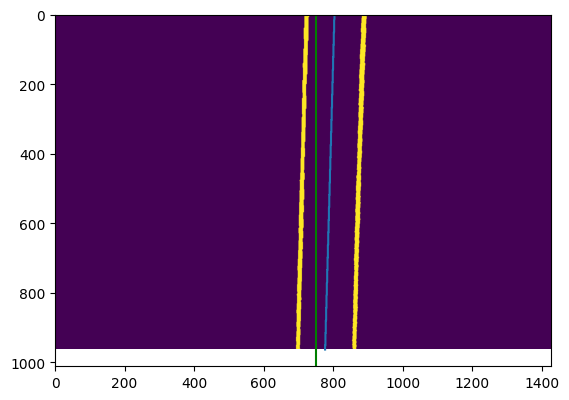

48


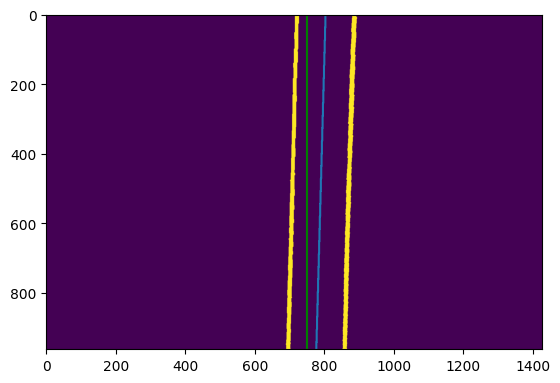

49


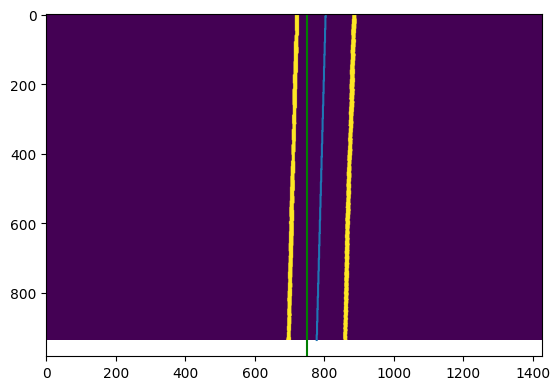

50


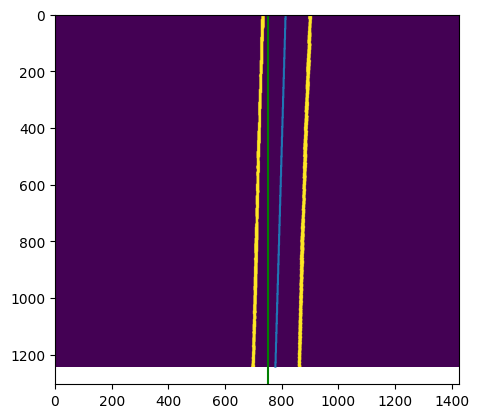

51


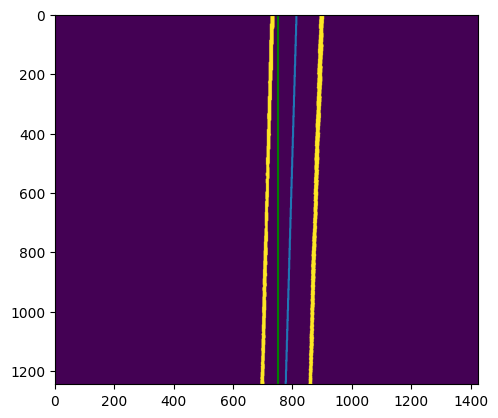

52


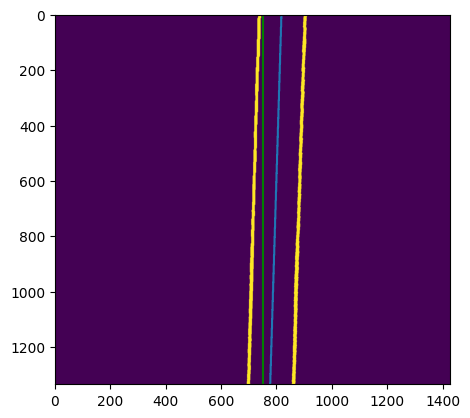

53


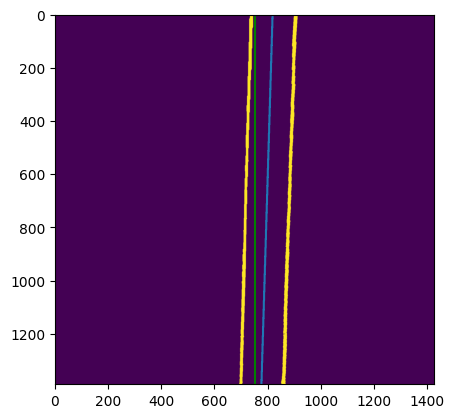

54


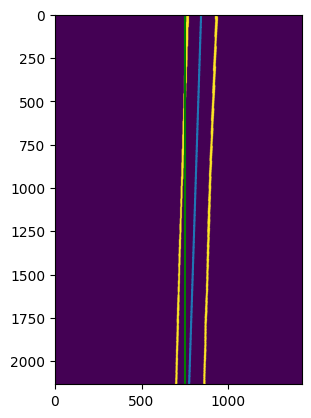

55


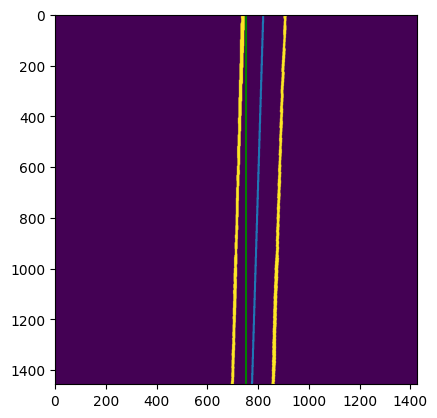

56


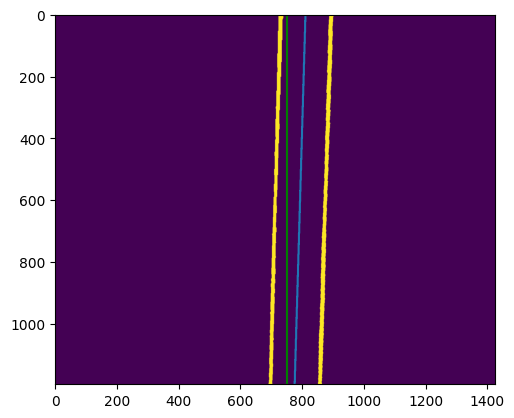

57


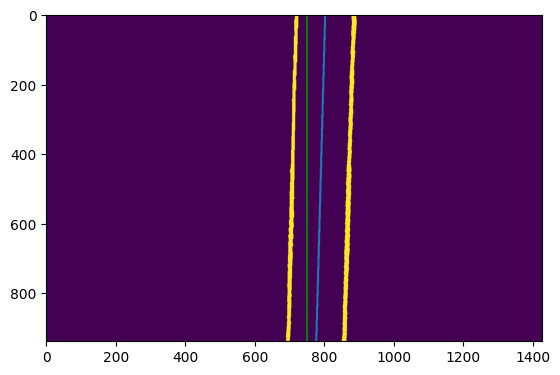

58


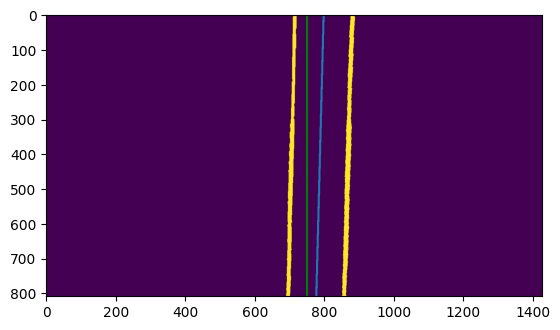

59


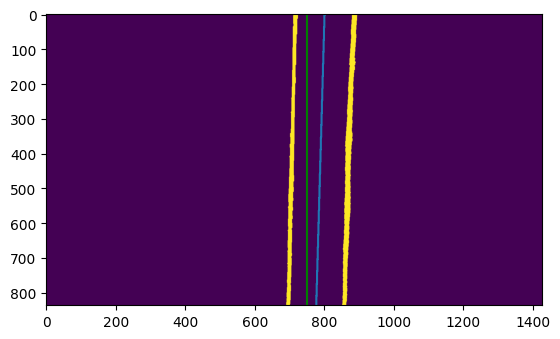

60


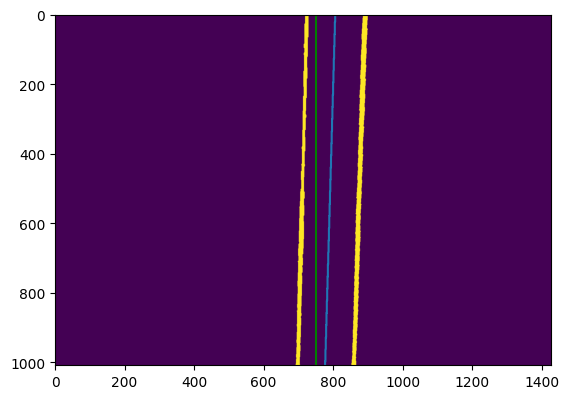

61


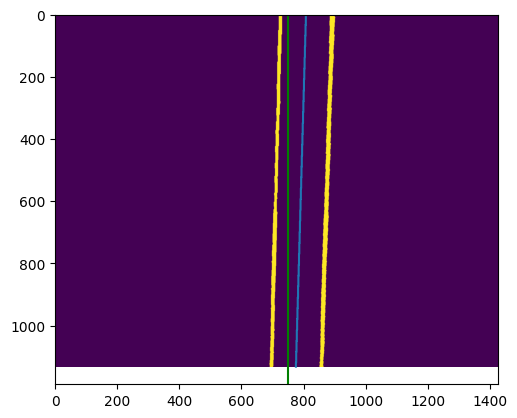

62


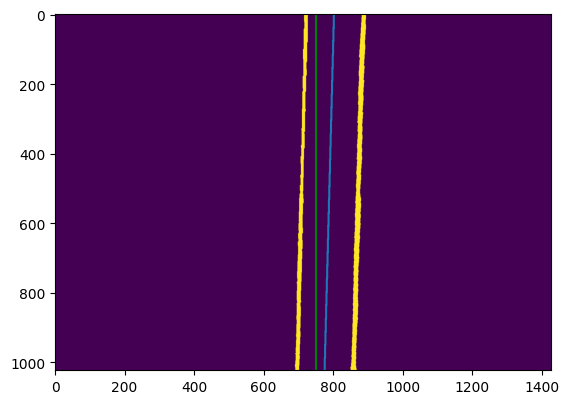

63


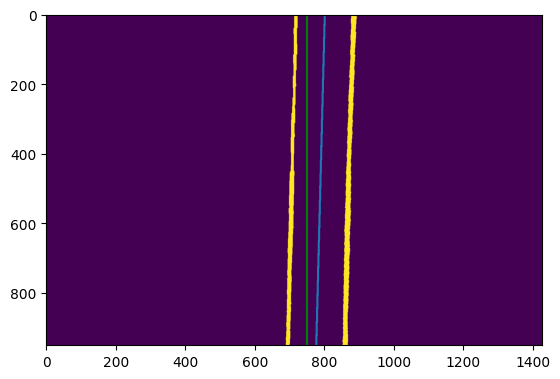

64


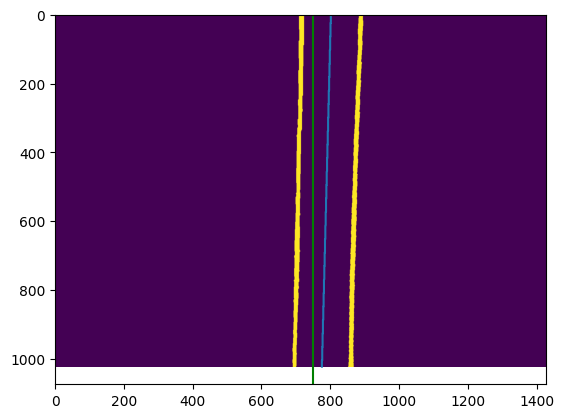

65


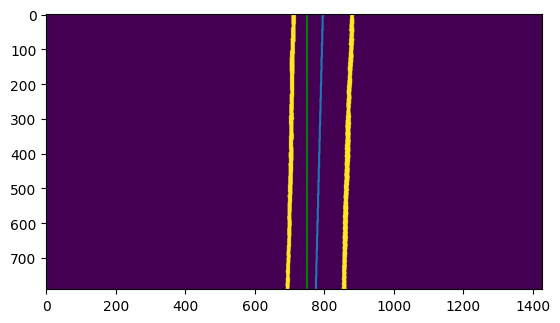

66


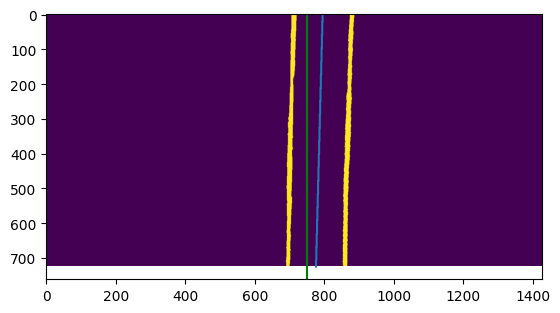

67


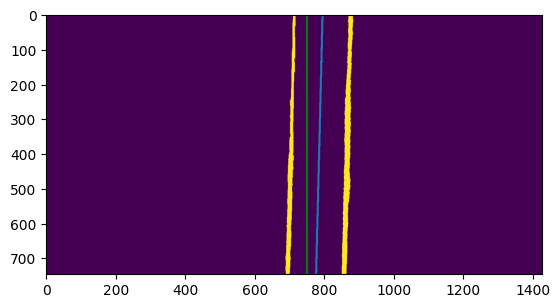

68


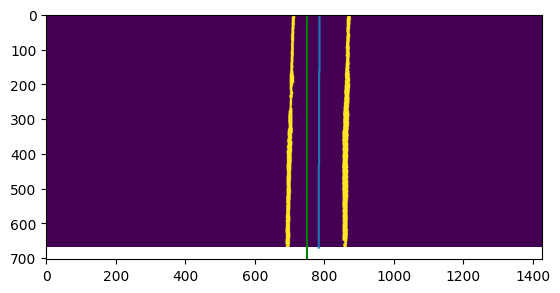

69


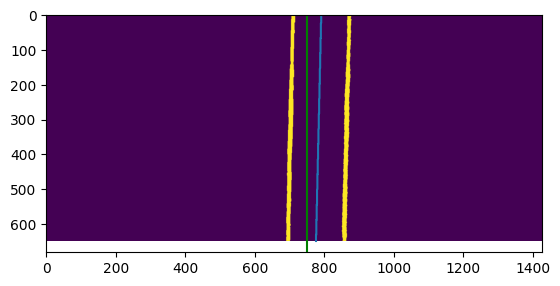

70


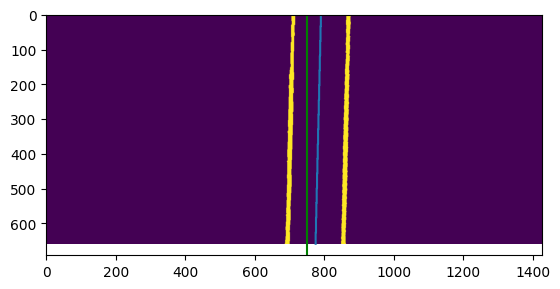

71


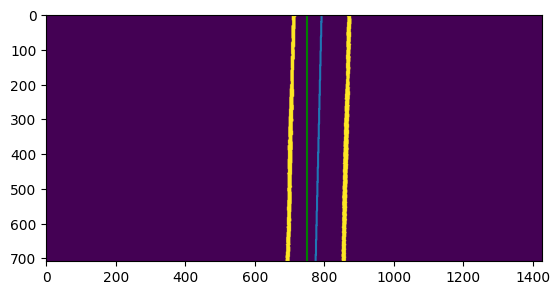

72


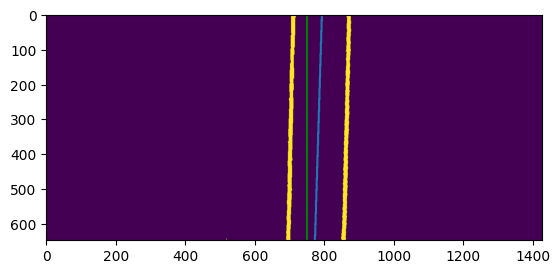

73


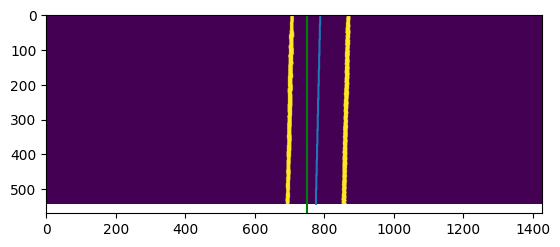

74


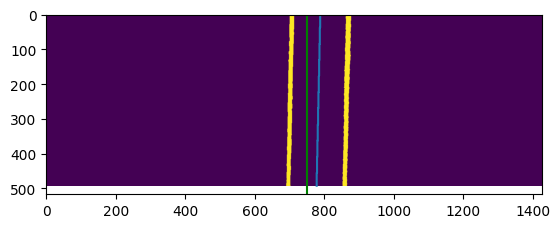

75


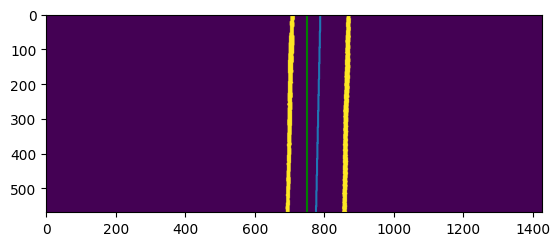

76


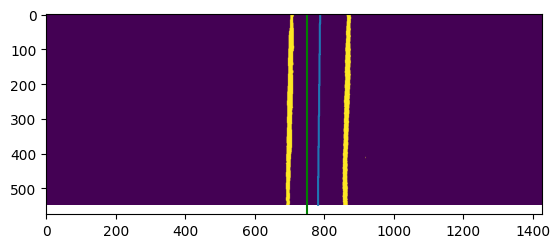

77


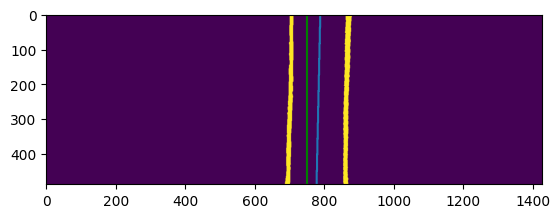

78


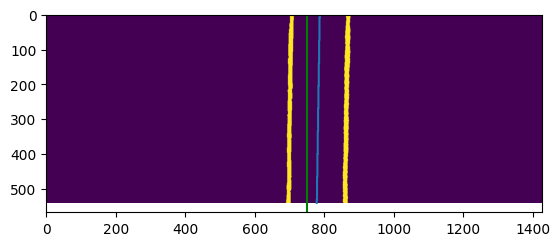

79


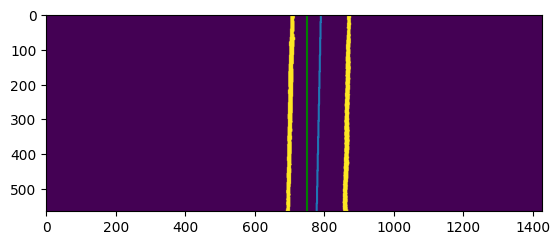

80


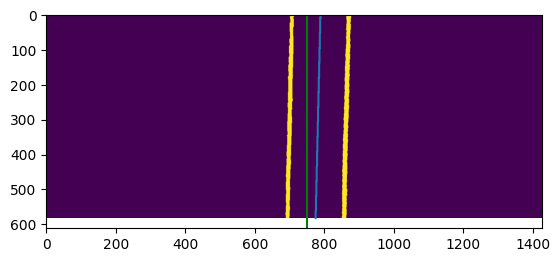

81


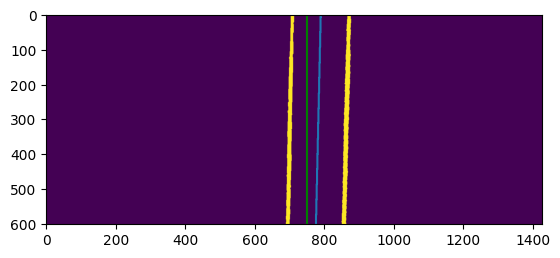

82


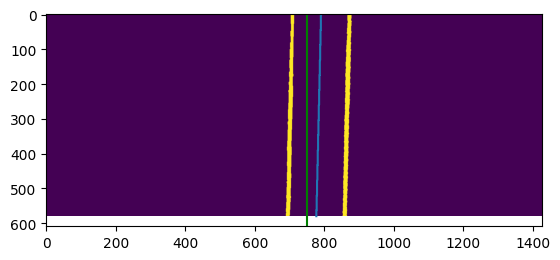

83


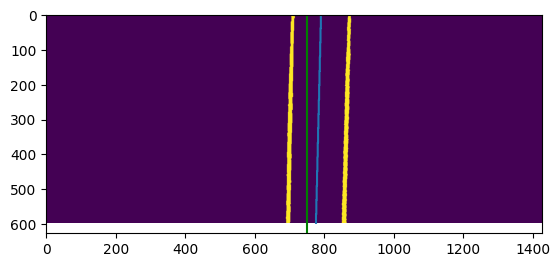

84


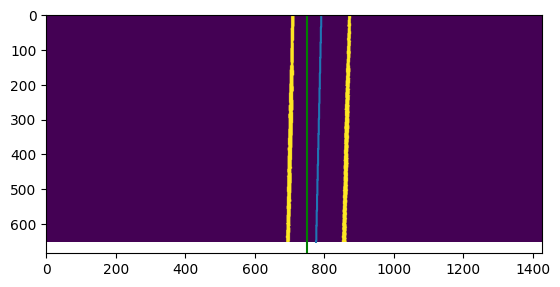

85


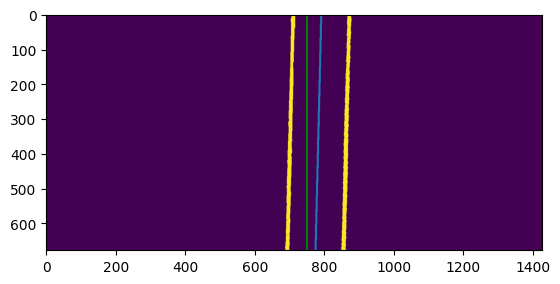

86


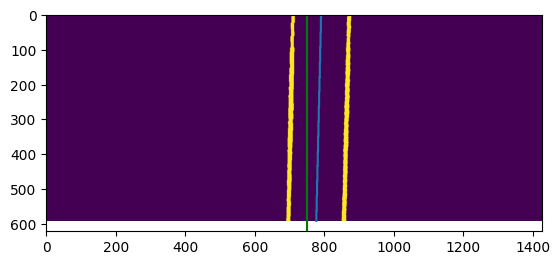

87


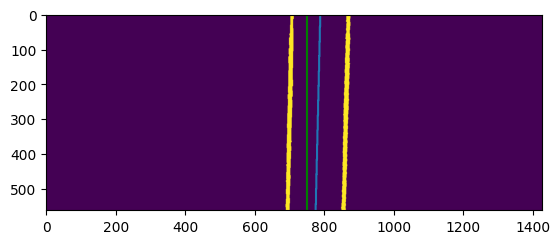

88


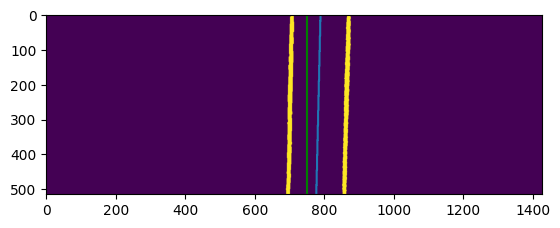

89


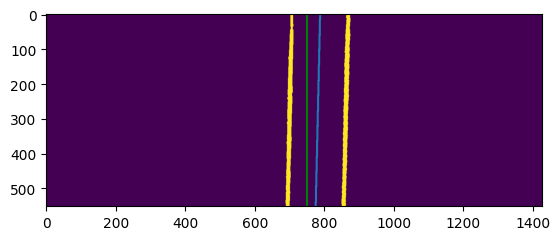

90


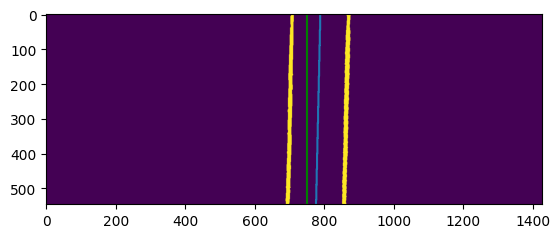

91


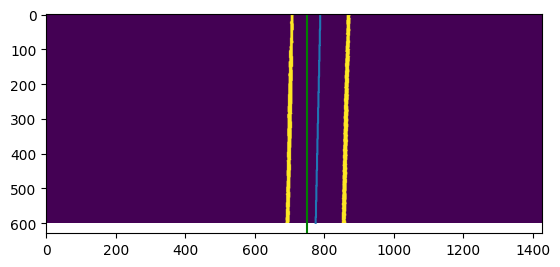

92


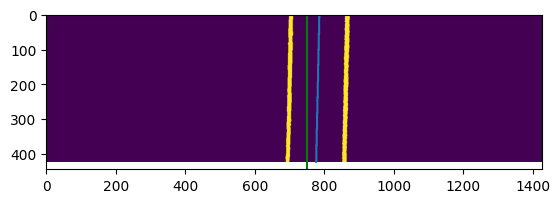

93


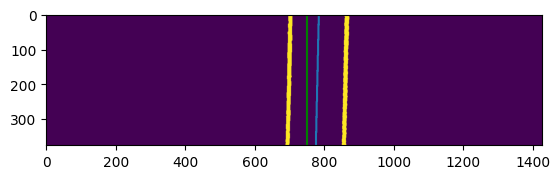

94


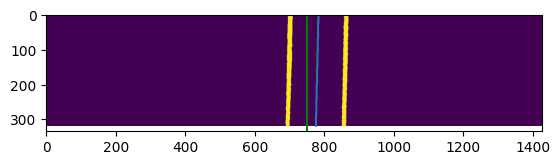

95


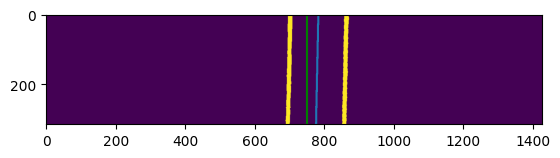

96


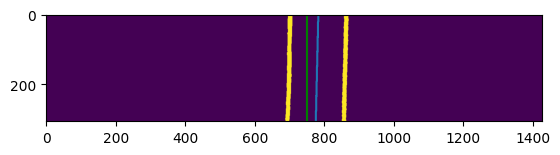

97


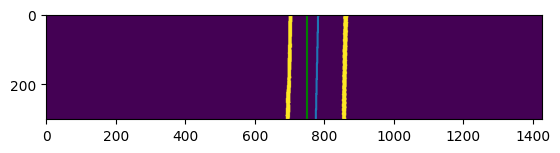

98


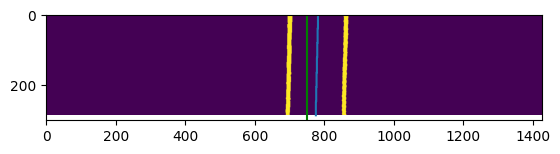

99


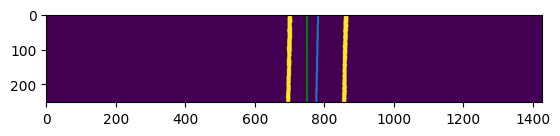

100


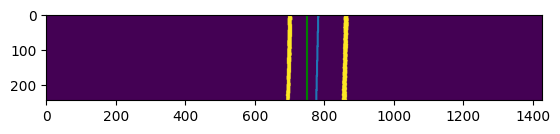

101


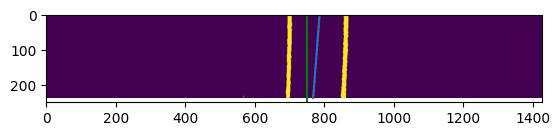

102


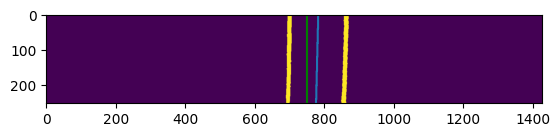

103


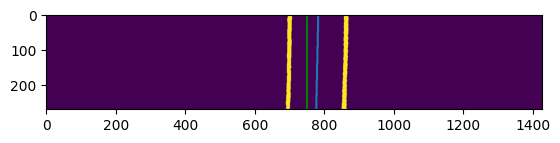

104


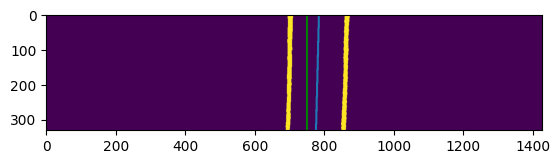

105


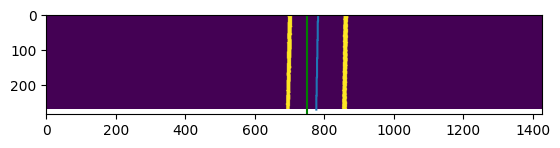

106


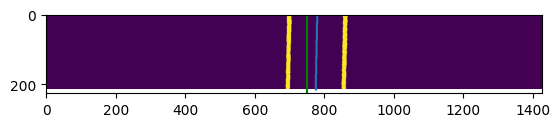

107


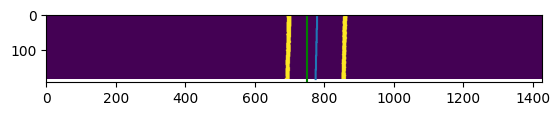

108


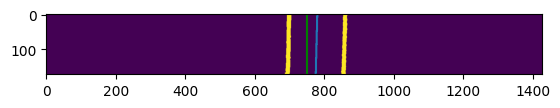

109


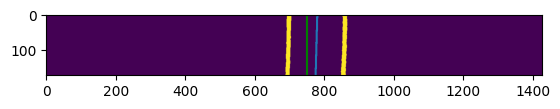

110


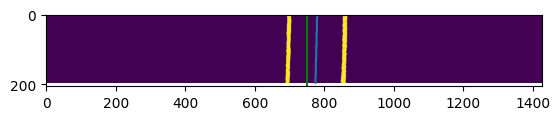

111


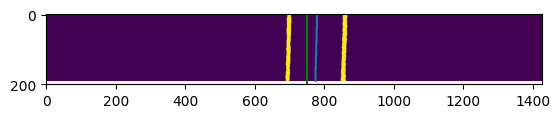

112


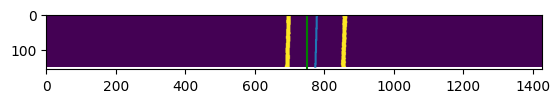

113


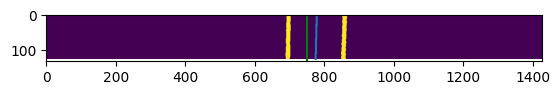

114


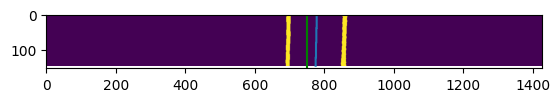

115


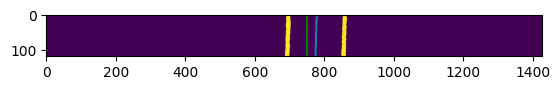

116


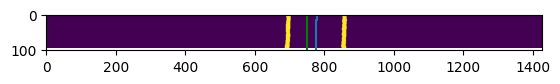

117


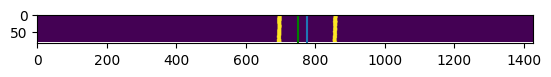

118


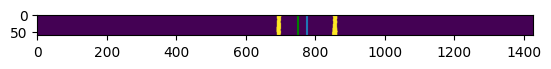

119


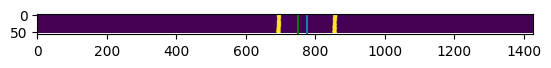

120


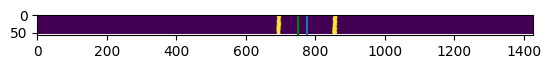

121


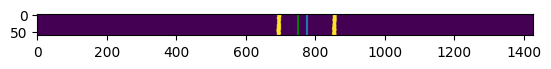

122


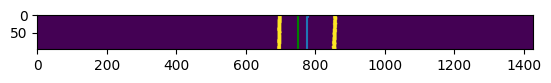

123


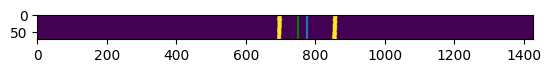

124


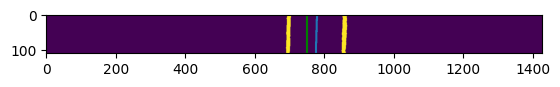

125


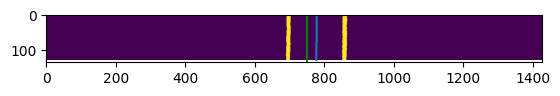

126


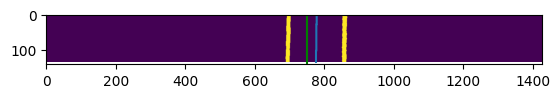

127


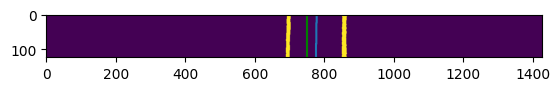

128


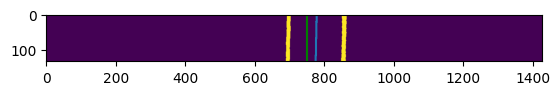

129


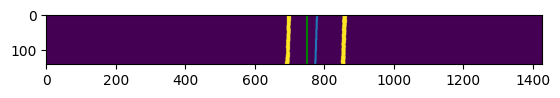

130


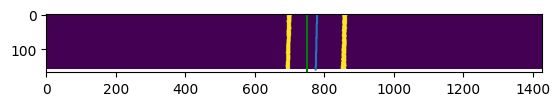

131


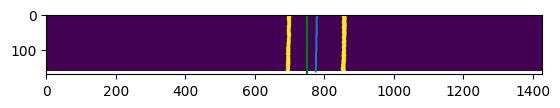

132


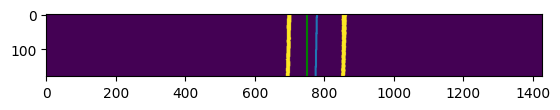

133


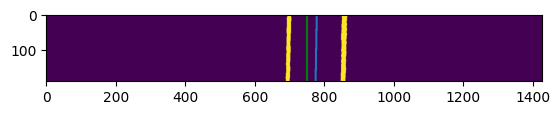

134


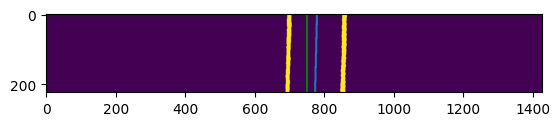

135


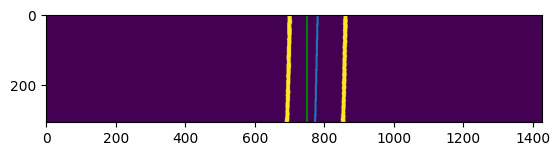

136


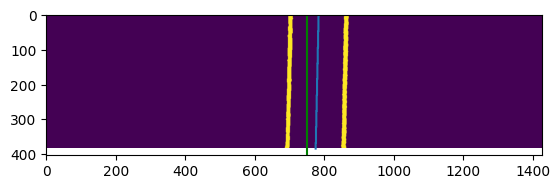

137


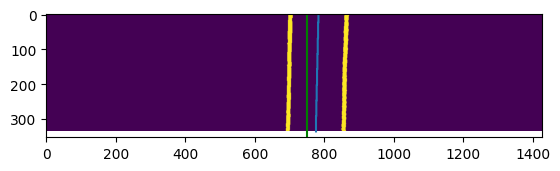

138


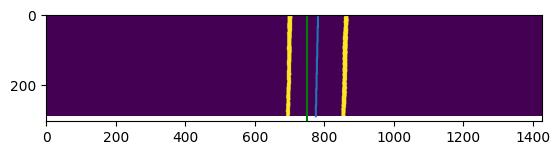

139


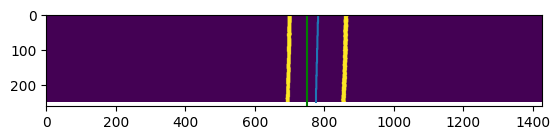

140


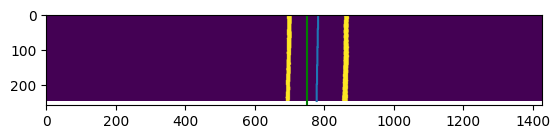

141


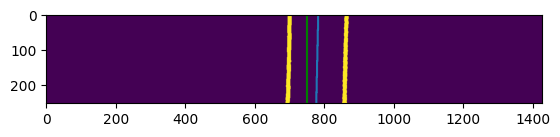

142


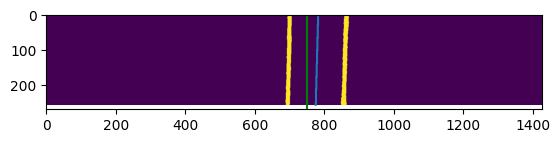

143


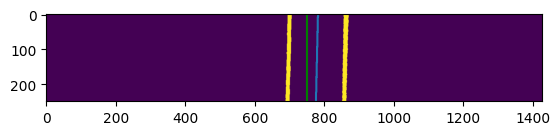

144


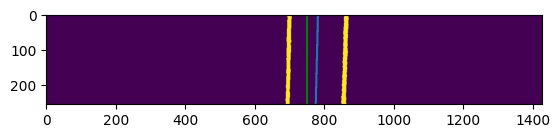

145


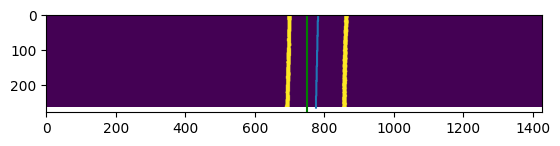

146


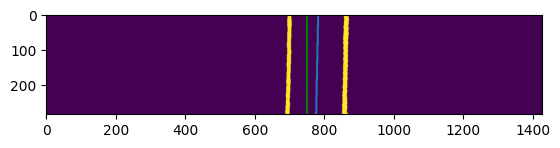

147


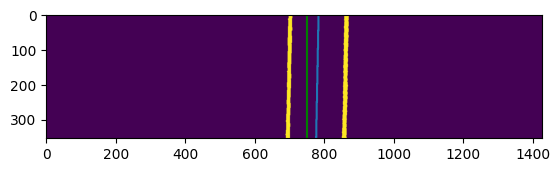

148


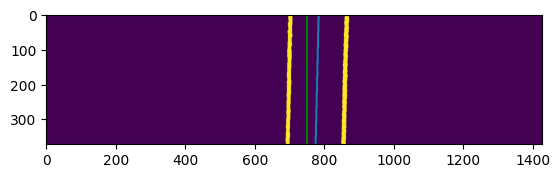

149


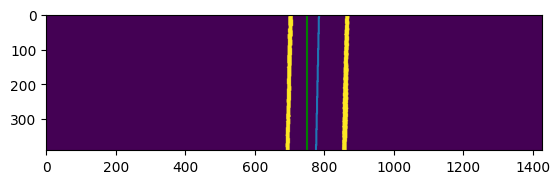

150


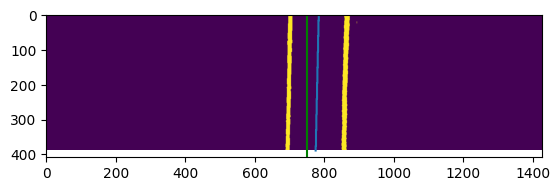

151


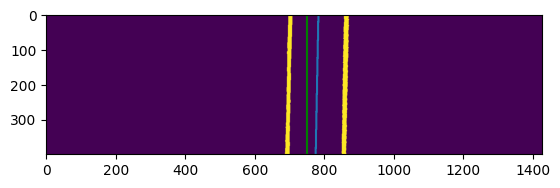

152


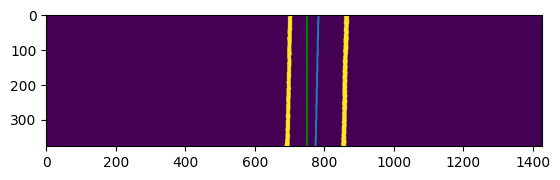

153


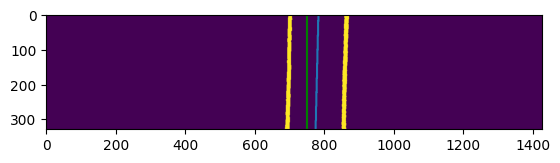

154


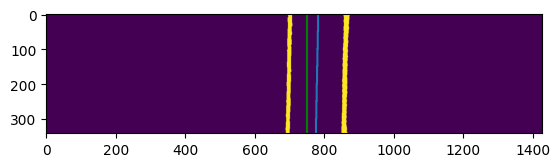

155


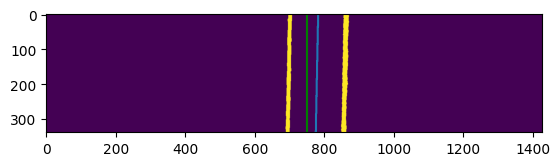

156


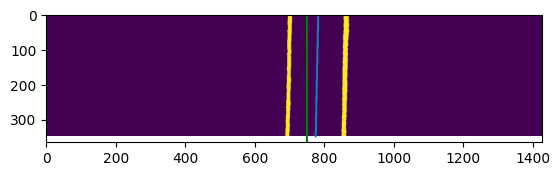

157


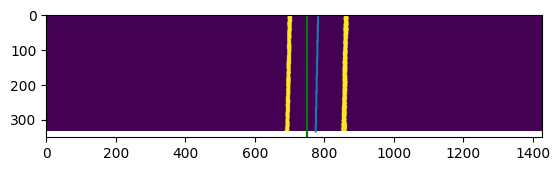

158


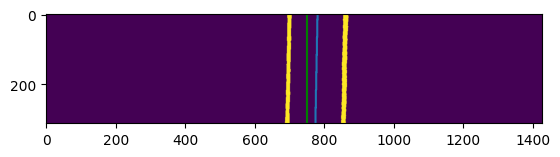

159


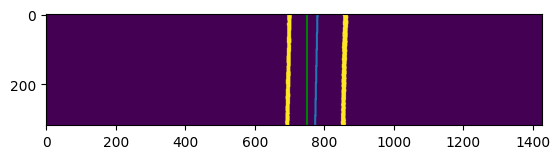

160


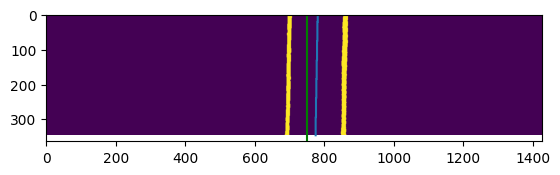

161


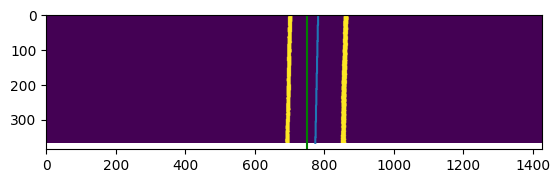

162


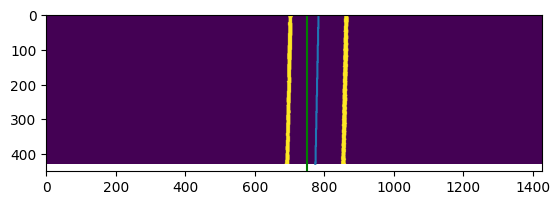

163


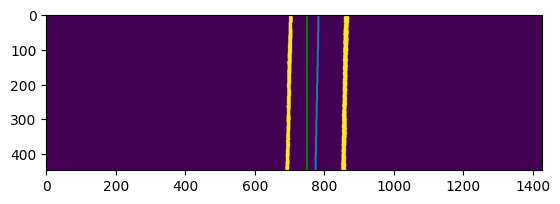

164


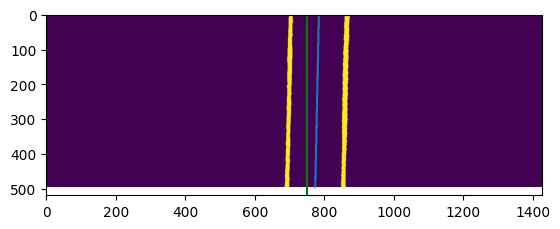

165


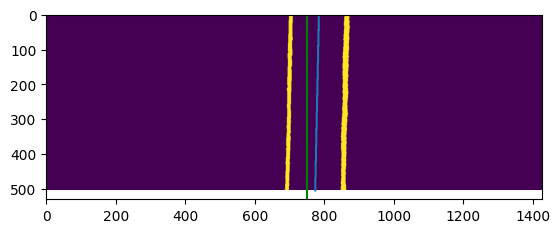

166


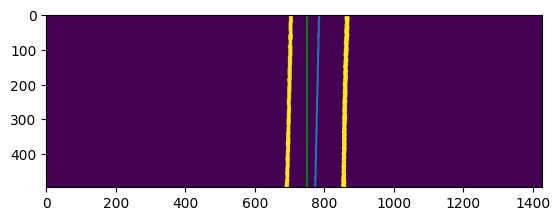

167


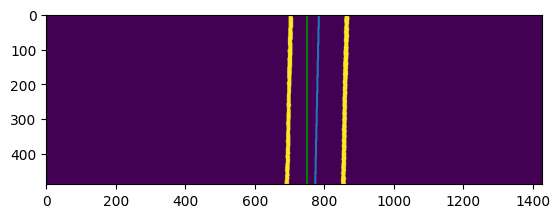

168


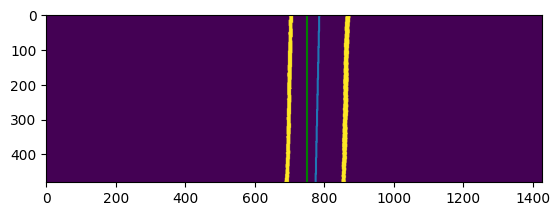

169


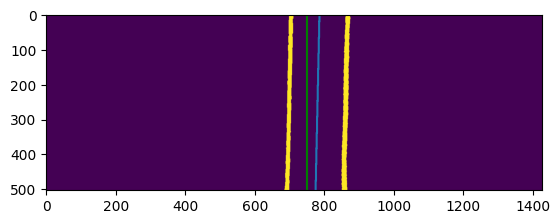

170


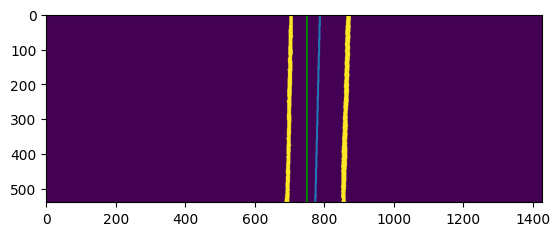

171


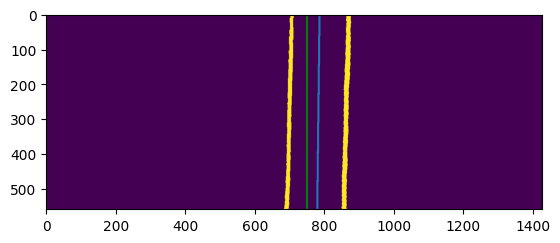

172


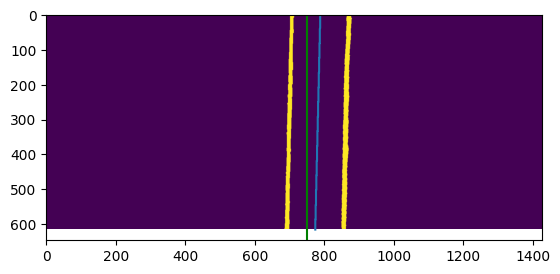

173


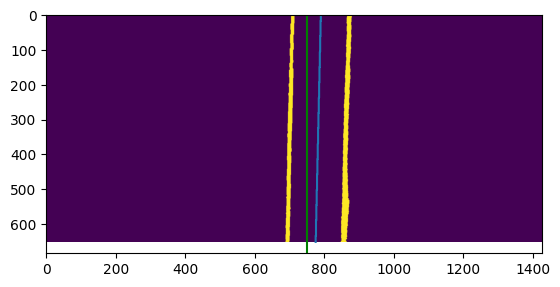

174


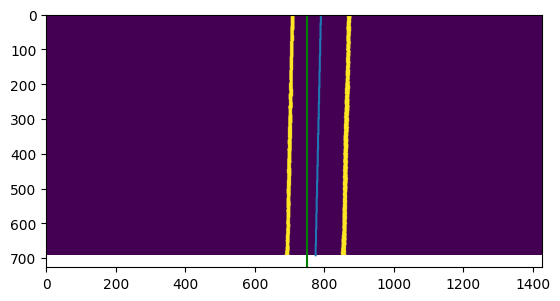

175


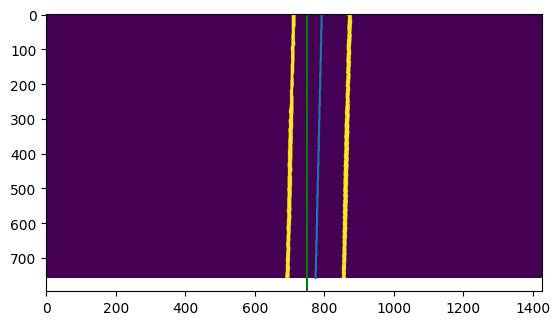

176


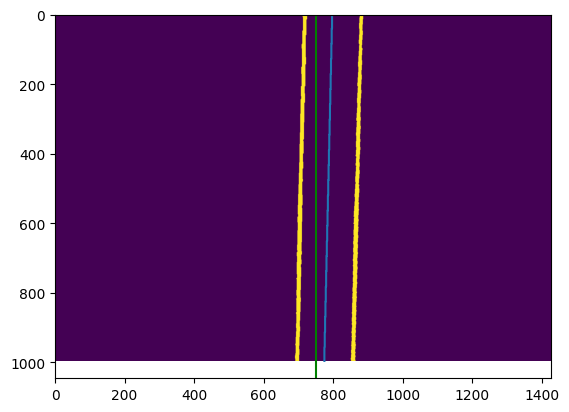

177


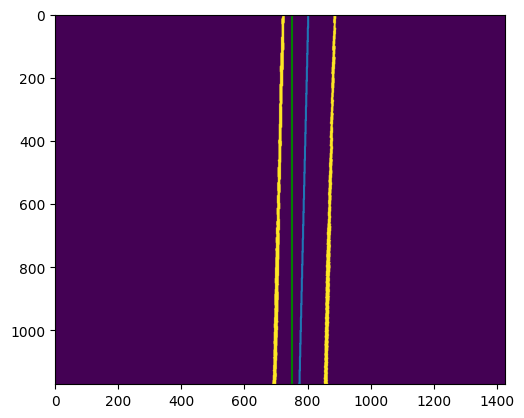

178


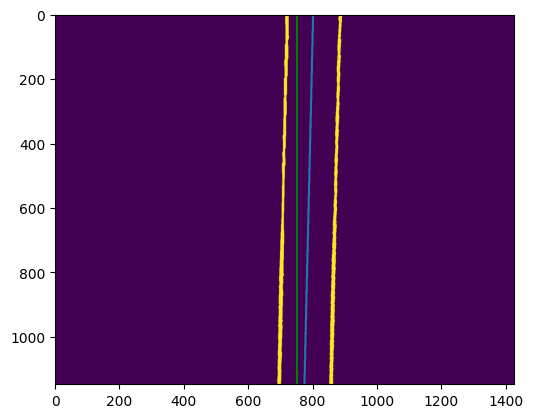

179


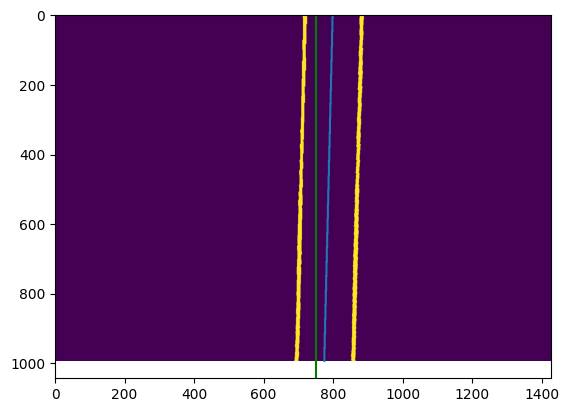

180


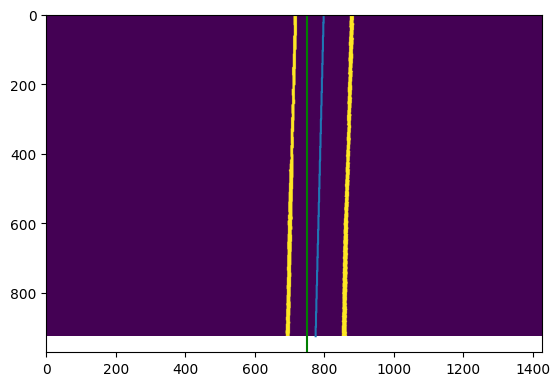

181


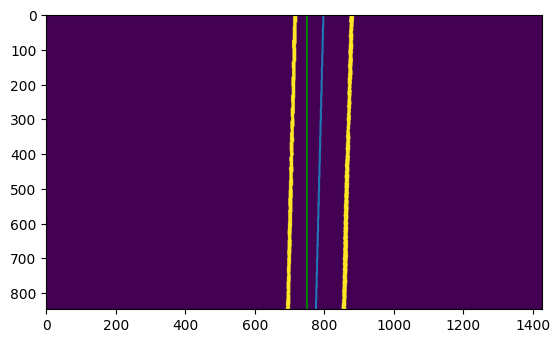

182


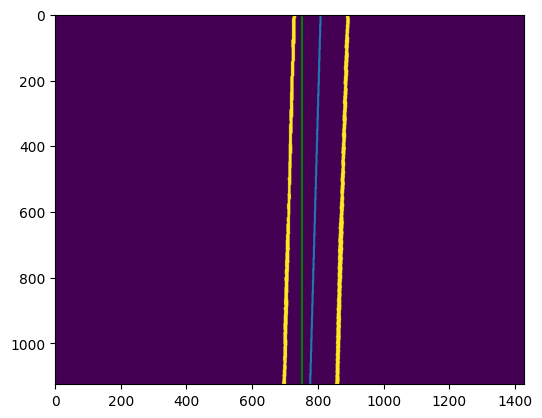

183


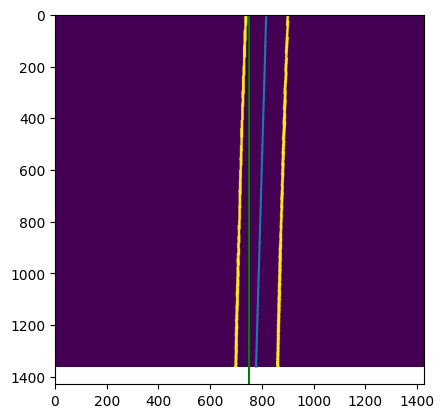

184


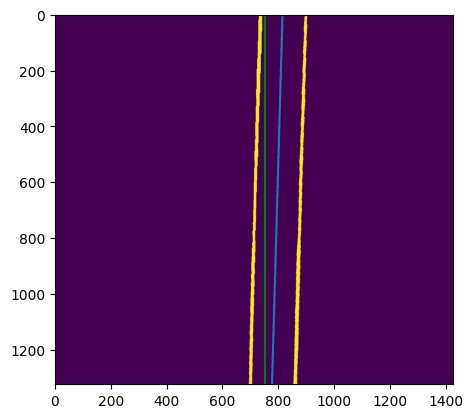

185


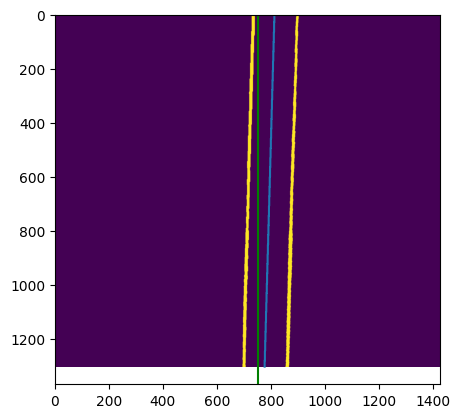

186


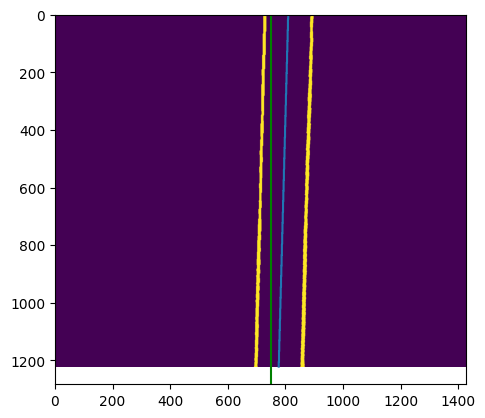

187


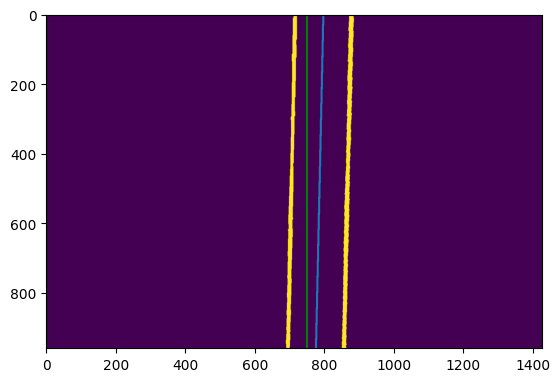

188


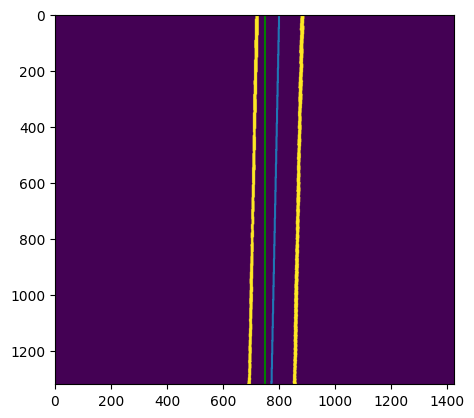

189


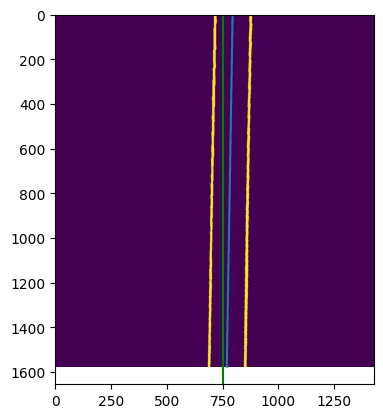

190


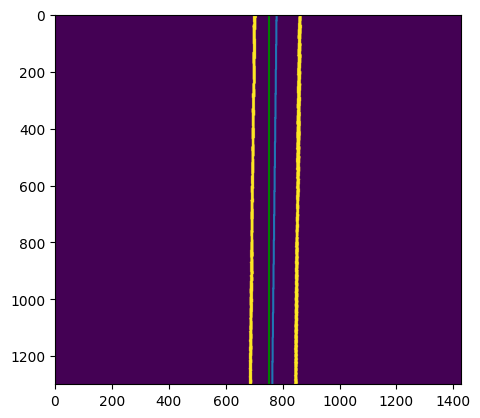

191


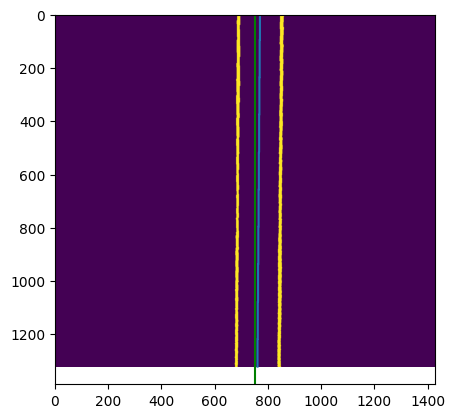

192


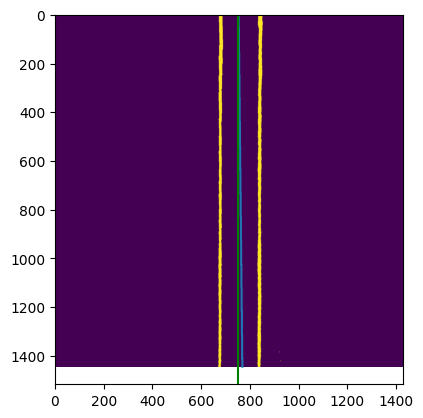

193


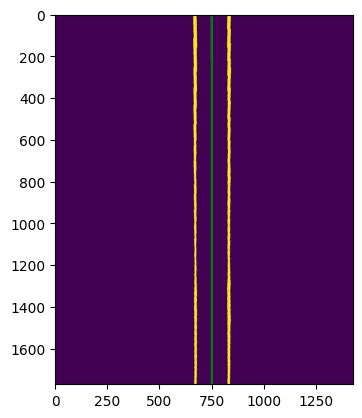

194


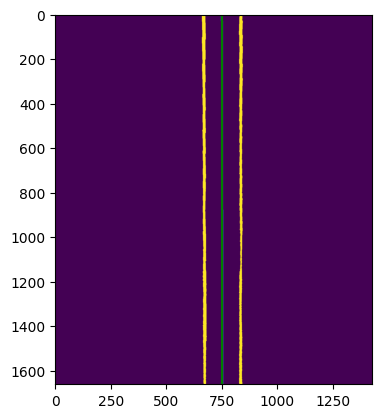

195


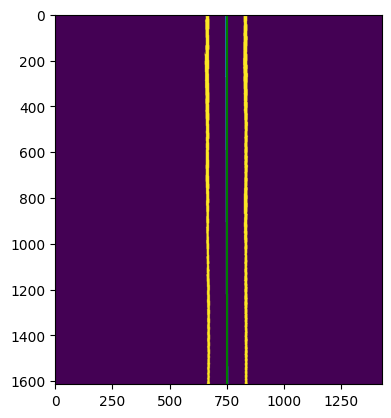

196


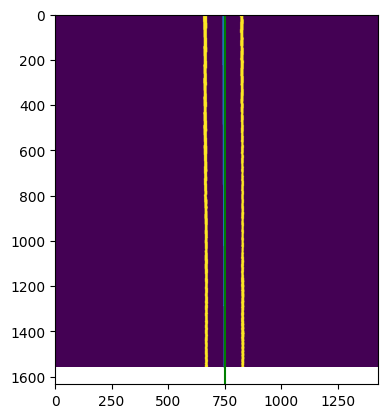

197


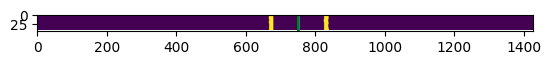

198


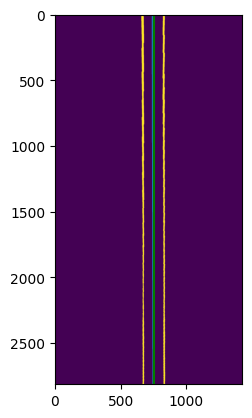

199


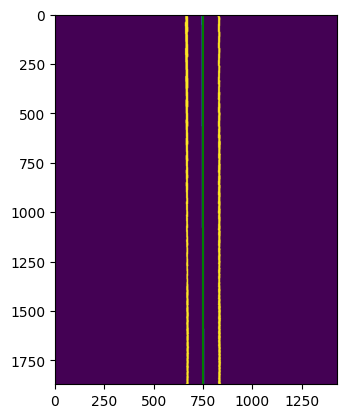

200


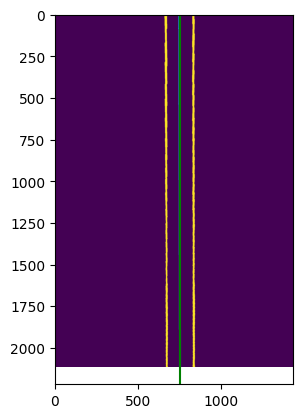

201


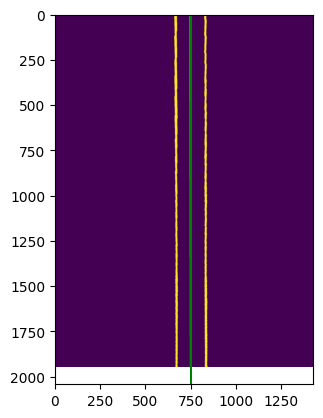

202


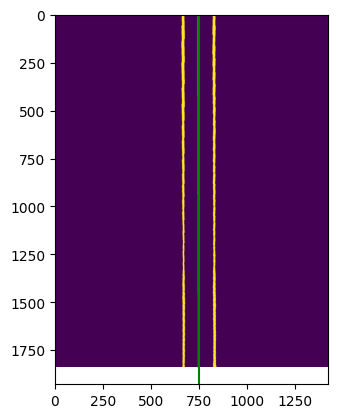

203


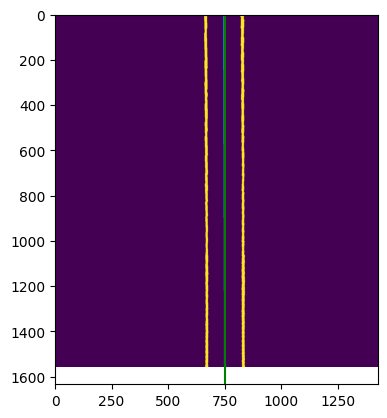

204


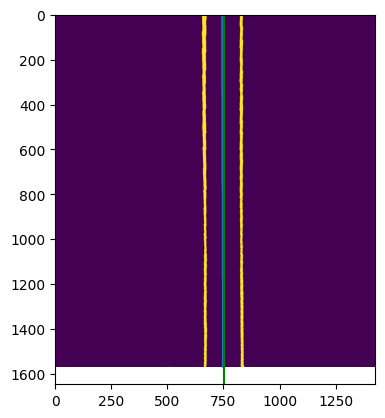

205


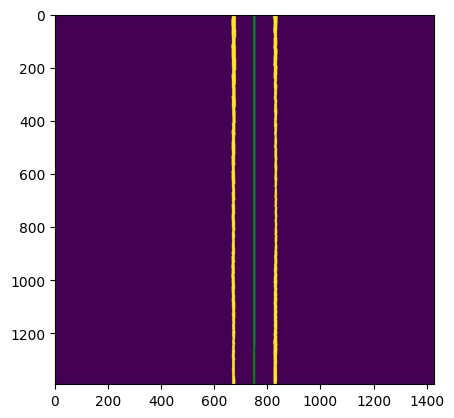

206


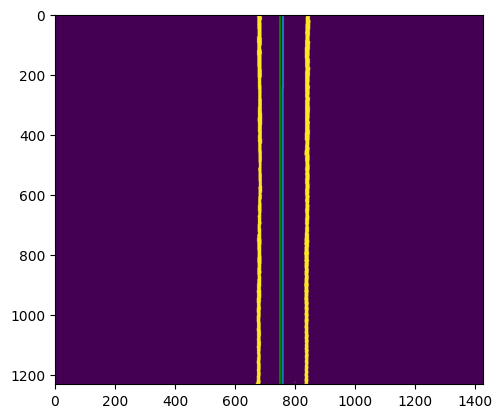

207


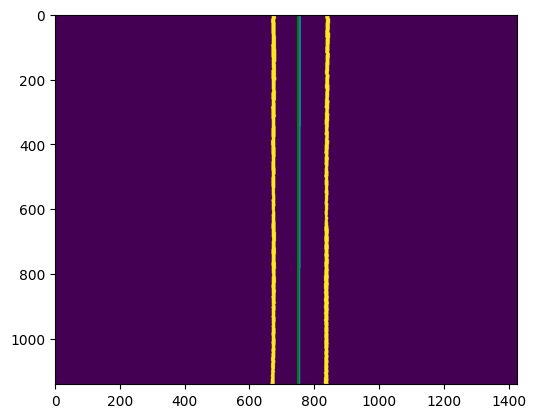

208


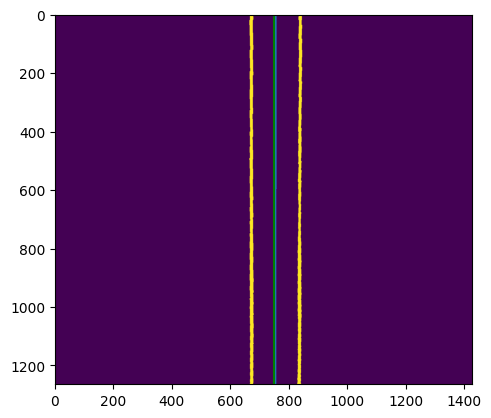

209


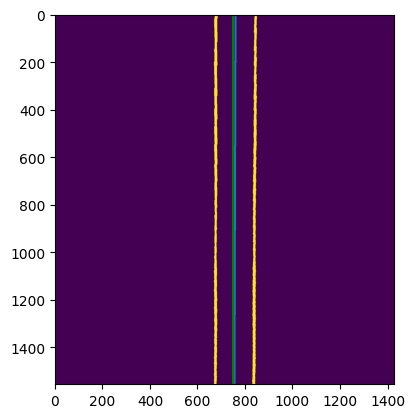

210


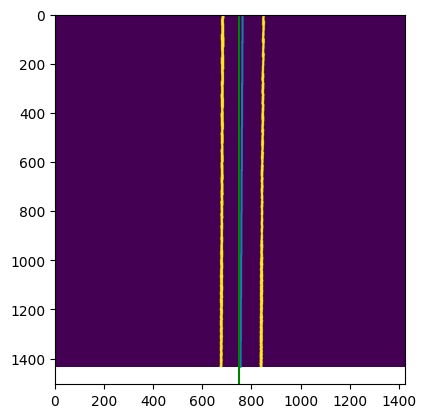

211


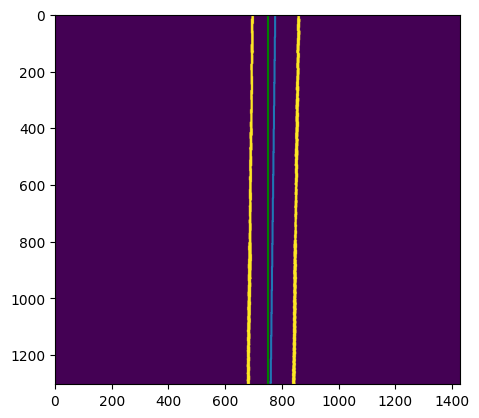

212


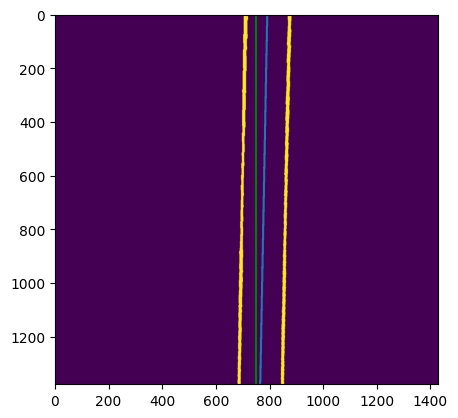

213


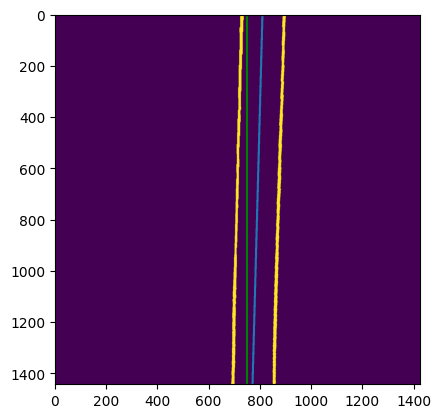

214


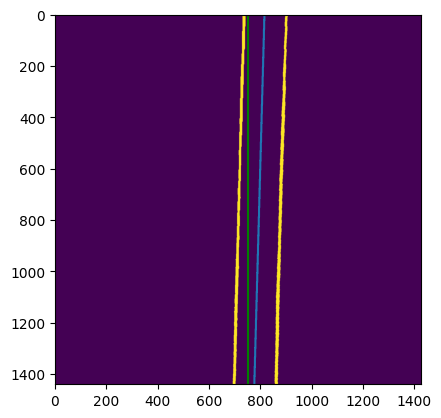

215


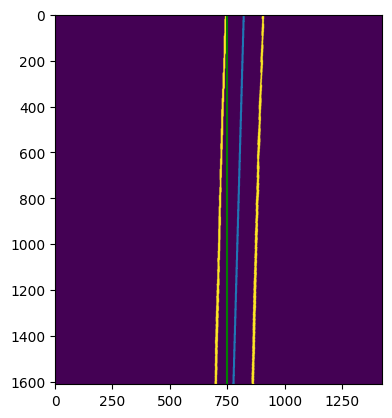

In [6]:
# проверить маски

for i, (m_f, c) in enumerate(zip(msk_fs[0:-1], coord[0:-1])):  # 0:-1 0:2 13:14 20:22 20:32 29:32
    mask = load_warp(m_f)
    mask = mask[mask.shape[0]-(coord[i+1] - coord[i]): mask.shape[0]+1]  # низ маски. низ - текущ коорд, верх след коорд (включительно)

    # mask = bend(mask, shift=2000)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=200)

    # преобразовать ось Y (переворот). Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    yx_centr = yx_centr.T
    _y = yx_centr[:, 0]
    _y = _y[::-1]
    yx_centr[:, 0] = _y
    # ===========================================

    # ===========================================
    # лин регрессия
    kb = np.polyfit(yx_centr[:, 0], yx_centr[:, 1], 1)
    f = np.poly1d(kb)
    y_n = np.arange(yx_centr.shape[0])
    x_lin = f(yx_centr[:, 0])
    yx_centr[:, 1] = x_lin
    # ===========================================
    print(i)
    plt.imshow(resize(mask))
    plt.plot(yx_centr[:, 1]//10, yx_centr[:, 0][::-1]//10)
    plt.axvline((mask.shape[1] // 20)+38, c='g')
    plt.margins(0, 0)
    plt.show()

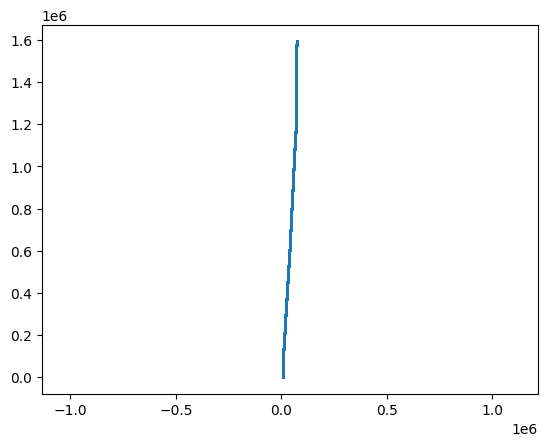

In [12]:
# вар № 3
# накапливать разницу углов в каждом кадре, на неё поворачивать
# yx_centr низ [-1], верх [0]

Array = np.zeros((1, 2))
angle_all = np.zeros((1))

x_norm = 7513

coef = 0.0
for i, (m_f, c) in enumerate(zip(msk_fs[0:-1], coord[0:-1])):  # 0:-1 0:2 13:14 20:22 20:32 29:32
    mask = load_warp(m_f)
    mask = mask[mask.shape[0]-(coord[i+1] - coord[i]): mask.shape[0]+1]  # низ маски. низ - текущ коорд, верх след коорд (включительно)

    # mask = bend(mask, shift=2000)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=200)

    # преобразовать ось Y (переворот). Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    yx_centr = yx_centr.T
    _y = yx_centr[:, 0]
    _y = _y[::-1]
    yx_centr[:, 0] = _y
    # ===========================================
    # plt.imshow(resize(mask))
    # plt.plot(yx_centr[:, 1]//10, yx_centr[:, 0][::-1]//10)
    # plt.axvline((mask.shape[1] // 20)+38, c='g')
    # plt.show()
    # ===========================================
    # лин регрессия
    kb = np.polyfit(yx_centr[:, 0], yx_centr[:, 1], 1)
    f = np.poly1d(kb)
    y_n = np.arange(yx_centr.shape[0])
    x_lin = f(yx_centr[:, 0])
    yx_centr[:, 1] = x_lin
    # ===========================================

    # текущий угол
    p1 = yx_centr[-1][::-1]
    p2 = yx_centr[0][::-1]
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    curr_angle = np.arctan2(dx, dy)
    # print('curr_angl', curr_angle)
    # print('p1', p1)
    # print('p2', p2)

    if i > 0:
        # смещение по У
        yx_centr[:, 0] += coef

        delta = curr_angle - prev_angle
        # print('delta', delta)
        angle += delta
        # print('angle', angle)

        # смещение по X
        shift = a - yx_centr[-1, 1]
        yx_centr[:, 1] += shift

        # поворот
        yx_centr = rotate(yx_centr[:, [1, 0]], -angle, yx_centr[-1, [1, 0]])[:, [1, 0]]
    else:
        angle = 0.0

    prev_angle = curr_angle
    # для смещения по Х
    a = yx_centr[0, 1]
    # обновл коорд Y на пройденный путь
    coef += yx_centr[0, 0] - yx_centr[-1, 0]  # shape тут не подходит, т.к. не измен после поворота


    Array = np.vstack((Array, yx_centr))
Array = Array[1:, :]  # убир перв строка, кот 0 0
plt.scatter(Array[:, 1], Array[:, 0], s=1)
plt.axis('equal')
plt.show()

-16.44262625067313
-9.810133341277833
-1.435933477458093
-6.6772299580288745
-18.606112434731585
-5.415147758850253
-6.892181544991217
-8.224472219212657
-14.717820270368065
-11.542595726901709
-3.489244035237789
16.341975841265594
58.79424055196978
118.76708964155569
219.58118458048284
350.2018441639957
291.6654375862636
369.78698406651347
354.9945732672777
305.21095861452613
325.7047418853963
339.11152023265095
270.4393858768144
203.72896474325717
235.34143015365953
239.54582705170196
245.42312289613983
252.5084395013846
194.89474724775118
157.5656618129142
159.33757822194912
207.42419961527776
258.67814354478014
278.5431482223912
221.49710852810767
194.67429768906186
200.58046880693473
212.7333242961995
288.6183575193518
321.67146095532644
430.0562214577931
357.1591468977067
307.91172287790505
232.4247893699512
245.79146858956574
305.6495748052166
301.9101728159885
267.16293368141305
266.00656462764437
255.79993461059894
358.86929372791747
363.0695812713775
405.0597512325139
419.356

(np.float64(-82012.29262939961),
 np.float64(562028.6639315928),
 np.float64(-44795.947484800745),
 np.float64(497491.5435298182))

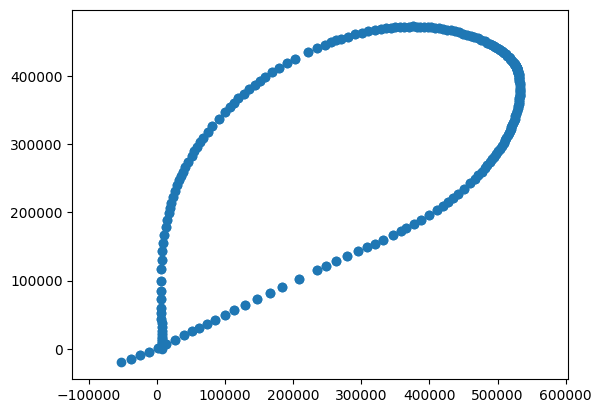

In [ ]:
# вар № 4
# нов, без накопления, от угла кривой кажд кадра
# yx_centr низ [-1], верх [0]

coords = []

for i, (m_f, c) in enumerate(zip(msk_fs[0:-1], coord[0:-1])):  # 0:-1 0:2 13:14 20:22 20:32 29:32 80:90
    # пройденный путь до след коорд
    L = (coord[i+1] - coord[i])

    mask = load_warp(m_f)
    mask = mask[mask.shape[0]-L: mask.shape[0]+1]  # низ маски. низ - текущ коорд, верх след коорд (включительно)

    # mask = bend(mask, shift=2000)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=200)
    # преобразовать ось Y (переворот). Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    yx_centr = yx_centr.T
    _y = yx_centr[:, 0]
    _y = _y[::-1]
    yx_centr[:, 0] = _y
    # ===========================================
    # лин регрессия
    kb = np.polyfit(yx_centr[:, 0], yx_centr[:, 1], 1)
    f = np.poly1d(kb)
    y_n = np.arange(yx_centr.shape[0])
    x_lin = f(yx_centr[:, 0])
    yx_centr[:, 1] = x_lin
    # ===========================================

    # угол наклона пути
    p1 = yx_centr[-1][::-1]
    p2 = yx_centr[0][::-1]
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    alpha_curr = np.arctan2(dx, dy)
    # print(alpha_curr)
    print(dx)

    # ================================
    # найти след точку с учетом предыдущ
    if i > 0:
        p1 = p2_next
        # delta =  alpha_curr - alpha_prev
        # alpha_curr += delta

        alpha_curr += alpha_prev
    # ================================

    # найти след точку в сист коорд
    unit_vector = np.array([np.sin(alpha_curr), np.cos(alpha_curr)])
    p2_next = p1 + L * unit_vector

    alpha_prev = alpha_curr

    coords.append([p1, p2_next])
coords = np.vstack(coords)
plt.scatter(coords[:, 0], coords[:, 1])
plt.axis('equal')


In [ ]:
[np.int32(i) for i in (b0, _b0, b)]

[array([7807, 7699], dtype=int32),
 array([ 7807, 14398], dtype=int32),
 array([ 7985, 14398], dtype=int32)]

In [ ]:
# вар № 4
# поворачивать предыдущий

# по смещению дельта Х
# yx_centr низ [-1], верх [0]
x_norm = 7513
coords = []
glob_angle = .0

for i, (m_f, c) in enumerate(zip(msk_fs[20:32], coord[20:32])):  # 0:-1 0:2 13:14 20:22 20:32 20:32 20:80 80:90
    # пройденный путь до след коорд
    L = (coord[i+1] - coord[i])

    mask = load_warp(m_f)
    mask = mask[mask.shape[0]-L: mask.shape[0]+1]  # низ маски. низ - текущ коорд, верх след коорд (включительно)

    # mask = bend(mask, shift=2000)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=200)
    # преобразовать ось Y (переворот). Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    yx_centr = yx_centr.T
    _y = yx_centr[:, 0]
    _y = _y[::-1]
    yx_centr[:, 0] = _y
    # ===========================================
    # лин регрессия
    kb = np.polyfit(yx_centr[:, 0], yx_centr[:, 1], 1)
    f = np.poly1d(kb)
    y_n = np.arange(yx_centr.shape[0])
    x_lin = f(yx_centr[:, 0])
    yx_centr[:, 1] = x_lin
    # ===========================================
    p1 = yx_centr[-1][::-1]
    p2 = yx_centr[0][::-1]
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]

    if i > 0:
        p1 = p2_real
